# **Importing the needed libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import silhouette_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, make_scorer)
from sklearn.model_selection import ( train_test_split, StratifiedKFold, cross_val_score, cross_validate, learning_curve, GridSearchCV)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.linear_model import LogisticRegression
import shap

# **Loading the dataset**

In [5]:
#loading the data
df = pd.read_csv("METABRIC_RNA_Mutation.csv")

/var/folders/3r/80rm85710xlfwfxk329qt65m0000gn/T/ipykernel_63945/2799364070.py:2: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [6]:
# show head
display(df.head())

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [7]:
#dataset shape
print("\n Shape:")
print(df.shape)


 Shape:
(1904, 693)


# **EDA**

This section aimed to explore the data and gain some knowledge about the data before modelling was undertaken. This assisted in finding the general trends, distribution and potential problems in the data.

**Data Basic Info**


In [8]:
#num of columns and rows
print("Number of Patients:", df.shape[0])
print("Number of Features:", df.shape[1])
print("\nData Types:\n")

print(df.dtypes.value_counts())

Number of Patients: 1904
Number of Features: 693

Data Types:

float64    498
str        186
int64        5
object       4
Name: count, dtype: int64


In [9]:
#columns names
for col in df.columns:
    print(col)

patient_id
age_at_diagnosis
type_of_breast_surgery
cancer_type
cancer_type_detailed
cellularity
chemotherapy
pam50_+_claudin-low_subtype
cohort
er_status_measured_by_ihc
er_status
neoplasm_histologic_grade
her2_status_measured_by_snp6
her2_status
tumor_other_histologic_subtype
hormone_therapy
inferred_menopausal_state
integrative_cluster
primary_tumor_laterality
lymph_nodes_examined_positive
mutation_count
nottingham_prognostic_index
oncotree_code
overall_survival_months
overall_survival
pr_status
radio_therapy
3-gene_classifier_subtype
tumor_size
tumor_stage
death_from_cancer
brca1
brca2
palb2
pten
tp53
atm
cdh1
chek2
nbn
nf1
stk11
bard1
mlh1
msh2
msh6
pms2
epcam
rad51c
rad51d
rad50
rb1
rbl1
rbl2
ccna1
ccnb1
cdk1
ccne1
cdk2
cdc25a
ccnd1
cdk4
cdk6
ccnd2
cdkn2a
cdkn2b
myc
cdkn1a
cdkn1b
e2f1
e2f2
e2f3
e2f4
e2f5
e2f6
e2f7
e2f8
src
jak1
jak2
stat1
stat2
stat3
stat5a
stat5b
mdm2
tp53bp1
adam10
adam17
aph1a
aph1b
arrdc1
cir1
ctbp1
ctbp2
cul1
dll1
dll3
dll4
dtx1
dtx2
dtx3
dtx4
ep300
fbxw7
hda

In [10]:
# Numerical columns
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical columns
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

print("\nNumber of Numerical Features:", len(numerical_cols))

print("Number of Categorical Features:", len(categorical_cols))


Number of Numerical Features: 503
Number of Categorical Features: 190


/var/folders/3r/80rm85710xlfwfxk329qt65m0000gn/T/ipykernel_63945/2530971029.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


overall_survival
0    1103
1     801
Name: count, dtype: int64


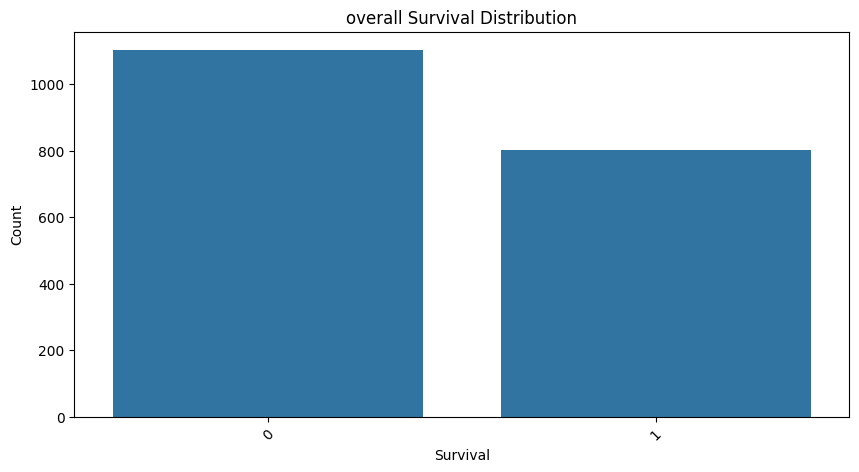

pam50_+_claudin-low_subtype
LumA           679
LumB           461
Her2           220
claudin-low    199
Basal          199
Normal         140
NC               6
Name: count, dtype: int64


/var/folders/3r/80rm85710xlfwfxk329qt65m0000gn/T/ipykernel_63945/3917220405.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


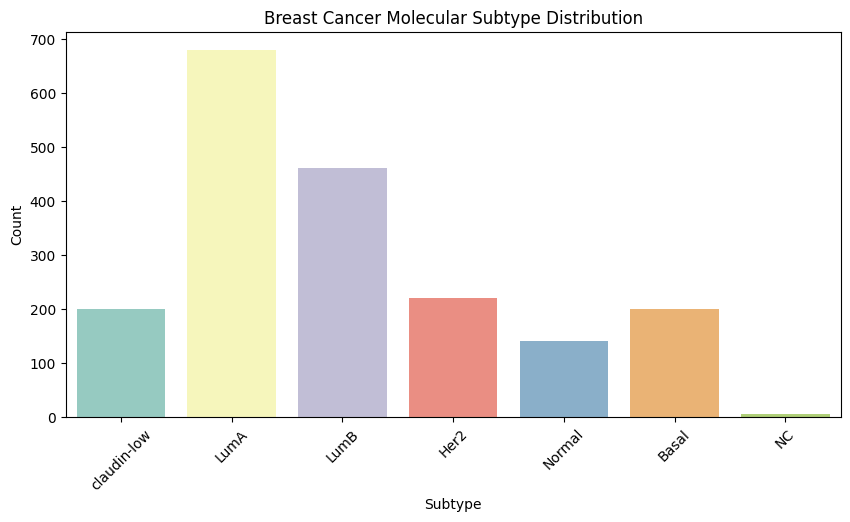

In [11]:
#target column
#survival
print(df["overall_survival"].value_counts())

# survival distirbution
plt.figure(figsize=(10,5))
sns.countplot(
    x="overall_survival",
    data=df,
)
plt.title("overall Survival Distribution")
plt.xlabel("Survival")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#subtypes
print(df["pam50_+_claudin-low_subtype"].value_counts())
# subtype distirbution
plt.figure(figsize=(10,5))
sns.countplot(
    x="pam50_+_claudin-low_subtype",
    data=df,
    palette="Set3"
)
plt.title("Breast Cancer Molecular Subtype Distribution")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [12]:
#missing values check
missing = df.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False)
print("\ncolumns with most missing values:")
print(missing.head(20))


columns with most missing values:
tumor_stage                       501
3-gene_classifier_subtype         204
primary_tumor_laterality          106
neoplasm_histologic_grade          72
cellularity                        54
mutation_count                     45
er_status_measured_by_ihc          30
type_of_breast_surgery             22
tumor_size                         20
cancer_type_detailed               15
tumor_other_histologic_subtype     15
oncotree_code                      15
death_from_cancer                   1
dtype: int64


In [13]:
#duplicates check
duplicates = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [20]:
#Summary describtion:
display(df.describe())

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1904.000000
mean,3921.982143,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,...,4.726891e-07,-3.676471e-07,-9.453782e-07,-1.050420e-07,-0.000002,3.676471e-07,4.726891e-07,7.878151e-07,0.000000,0.000000
std,2358.478332,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,...,1.000263e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000262,1.000264e+00,1.000262e+00,1.000263e+00,1.000262,1.000262
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,-2.120800e+00,-3.364800e+00,-2.719400e+00,-4.982700e+00,-2.981700,-3.833300e+00,-3.609300e+00,-1.166900e+00,-2.112600,-1.051600
25%,896.500000,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,...,-6.188500e-01,-6.104750e-01,-6.741750e-01,-6.136750e-01,-0.632900,-6.664750e-01,-7.102000e-01,-5.058250e-01,-0.476200,-0.726000
50%,4730.500000,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,...,-2.456500e-01,-4.690000e-02,-1.422500e-01,-5.175000e-02,-0.026650,7.000000e-04,-2.980000e-02,-2.885500e-01,-0.133400,-0.424800
75%,5536.250000,70.592500,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.040250,184.716667,...,3.306000e-01,5.144500e-01,5.146000e-01,5.787750e-01,0.590350,6.429000e-01,5.957250e-01,6.022500e-02,0.270375,0.428400
max,7299.000000,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,355.200000,...,6.534900e+00,1.027030e+01,6.329000e+00,4.571300e+00,12.742300,3.938800e+00,3.833400e+00,1.088490e+01,12.643900,3.284400


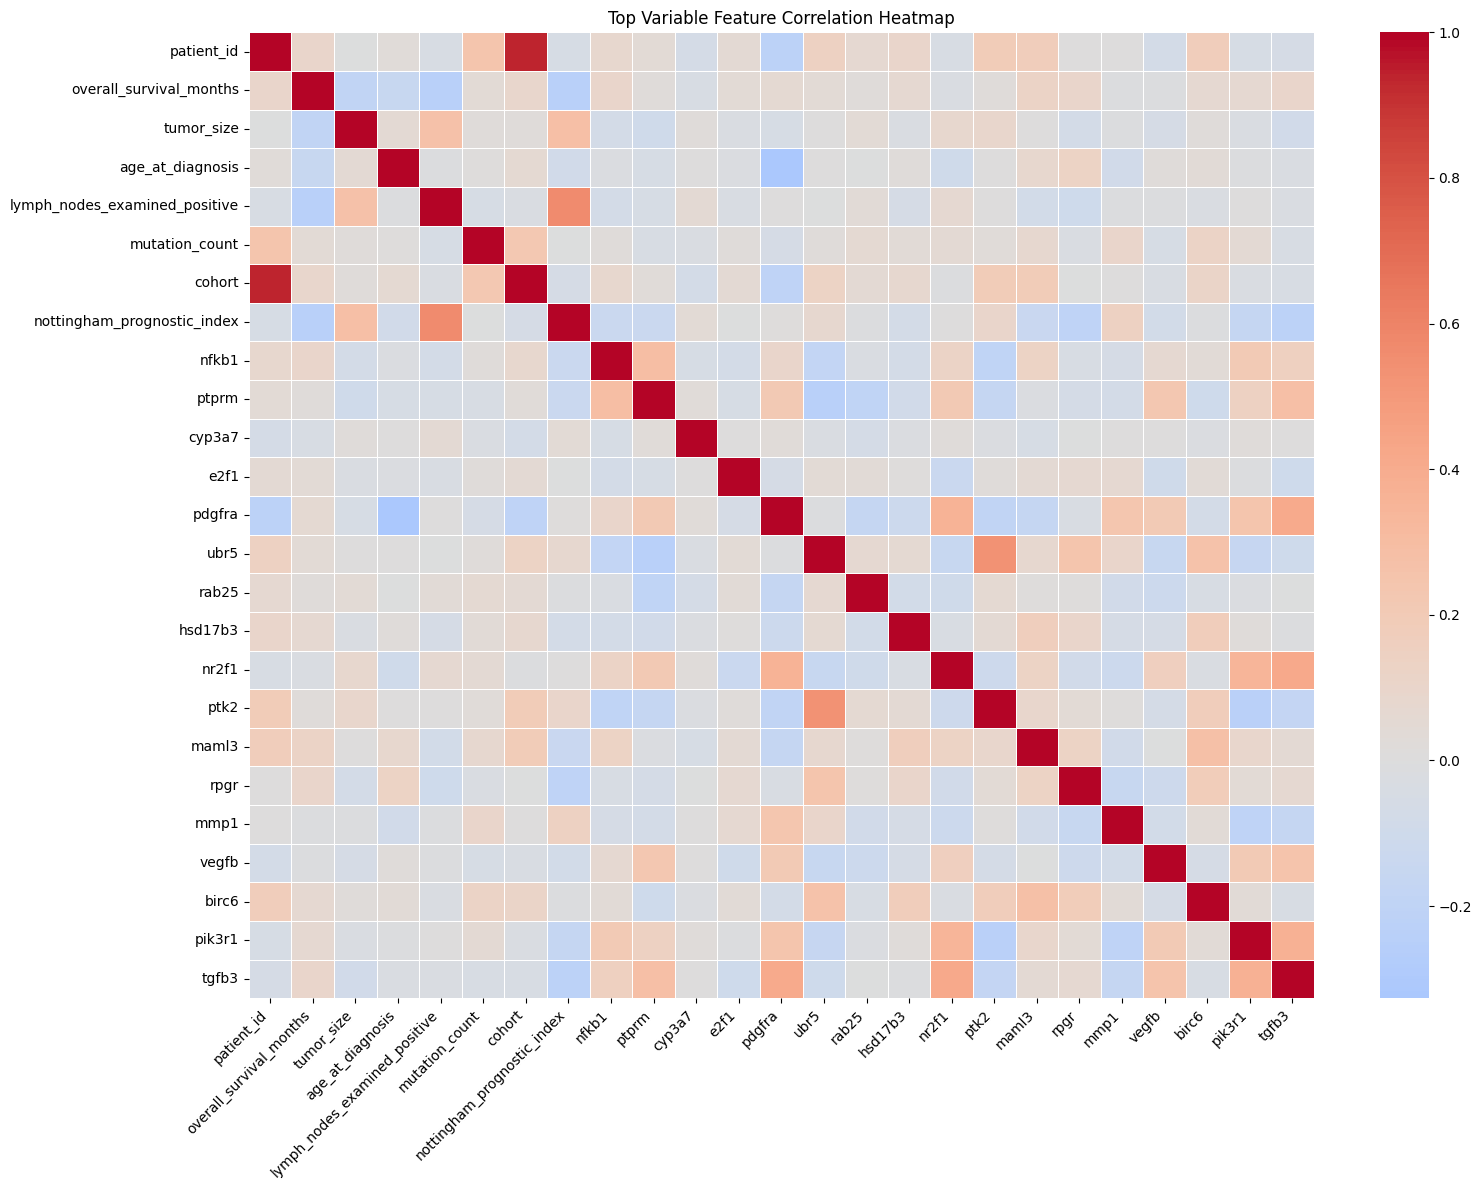

In [ ]:
# Select top numerical features with strongest corelation only
top_features =  df[numerical_cols].var().sort_values(ascending=False).head(25).index
corr_matrix = df[top_features].corr()

plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Top Variable Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show() 

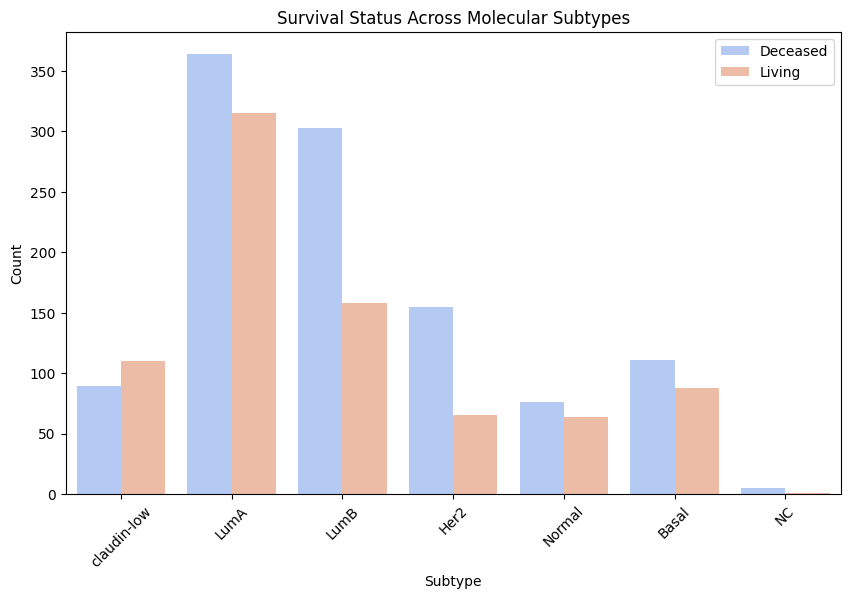

In [ ]:
# Survival Status by Subtype
plt.figure(figsize=(10,6))
sns.countplot(
    x="pam50_+_claudin-low_subtype",
    hue="overall_survival",
    data=df,
    palette="coolwarm"
)
plt.title("Survival Status Across Molecular Subtypes")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Deceased", "Living"])
plt.show()

/var/folders/3r/80rm85710xlfwfxk329qt65m0000gn/T/ipykernel_63945/4069726127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


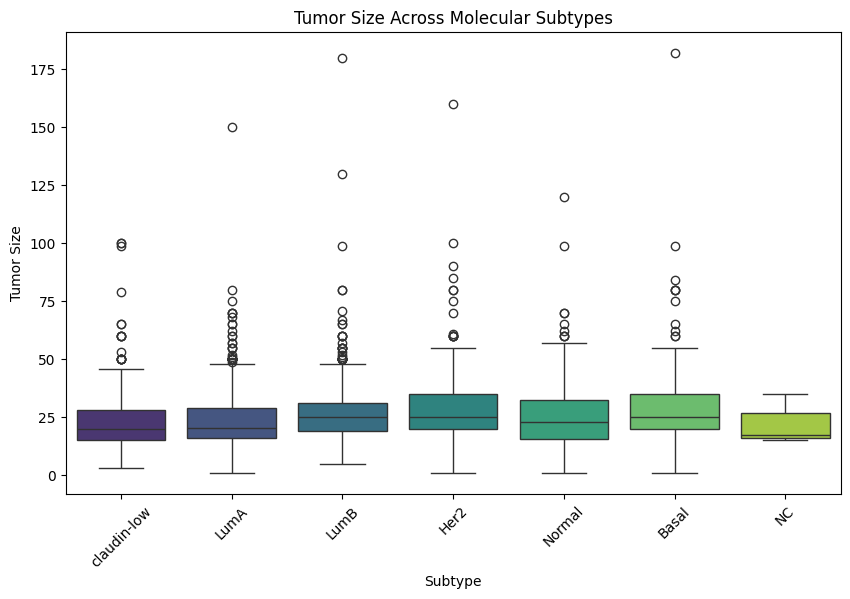

In [18]:
# Tumor Size by Subtype
plt.figure(figsize=(10,6))
sns.boxplot(
    x="pam50_+_claudin-low_subtype",
    y="tumor_size",
    data=df,
    palette="viridis"
)
plt.title("Tumor Size Across Molecular Subtypes")
plt.xlabel("Subtype")
plt.ylabel("Tumor Size")
plt.xticks(rotation=45)

plt.show()

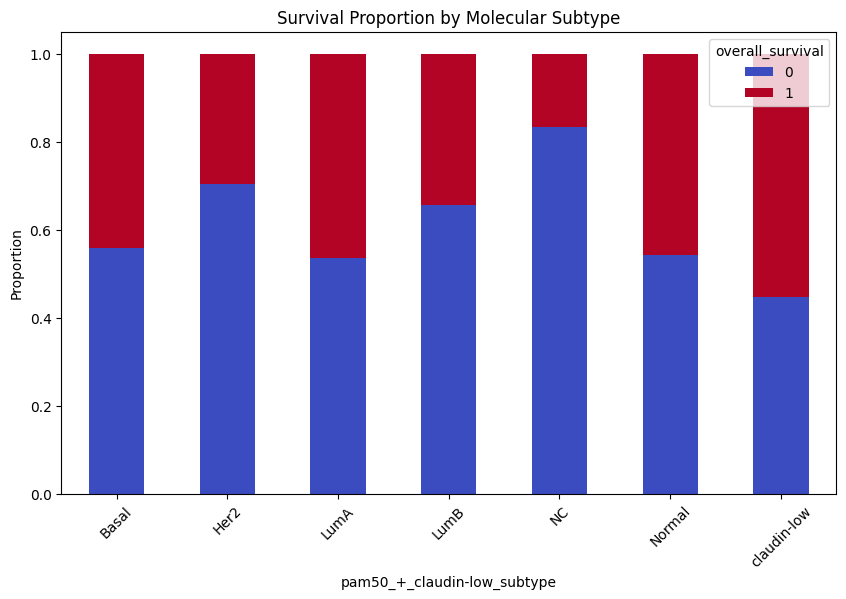

In [ ]:
#survival percentage per subtype
survival_rate = pd.crosstab(
    df["pam50_+_claudin-low_subtype"],
    df["overall_survival"],
    normalize="index"
)

survival_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="coolwarm"
)

plt.title("Survival Proportion by Molecular Subtype")

plt.ylabel("Proportion")

plt.xticks(rotation=45)

plt.show()

# **preprocessing**

The data in this section was cleaned and prepared for machine learning. This was done to ensure the clinical and gene expression features would be appropriate for training of the models.

In [21]:
# drop id cause it is unique and dosent add to my study
df.drop(columns=["patient_id"], inplace=True)
df.drop(columns = ["death_from_cancer"], inplace=True)
pam50_col = "pam50_+_claudin-low_subtype"

In [22]:
#setting target and features
X = df.drop(columns=["overall_survival"])
y = df["overall_survival"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (1904, 690)
Target Shape: (1904,)


In [23]:
#train test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42)

In [24]:
#Separating the data to gene expression only and clinical only
#gene expression data start at "brca1"
gene_start = X_train.columns.get_loc("brca1")

# Gene expression
X_train_gene = X_train.iloc[:, gene_start:]
X_test_gene = X_test.iloc[:, gene_start:]
feature_names_gene= X_train_gene.columns

# Clinical
X_train_clinical = X_train.iloc[:, :gene_start]
X_test_clinical = X_test.iloc[:, :gene_start]

In [25]:
#filling missing values
#dividing categorical and numerical columns
numerical_cols_gene = X_train_gene.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_gene = X_train_gene.select_dtypes(include=['object', 'category']).columns
numerical_cols_clinical = X_train_clinical.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_clinical = X_train_clinical.select_dtypes(include=['object', 'category']).columns

# imputation for numerical columns
num_imputer = SimpleImputer(strategy="median")
X_train_gene[numerical_cols_gene] = num_imputer.fit_transform(X_train_gene[numerical_cols_gene])
X_test_gene[numerical_cols_gene] = num_imputer.transform(X_test_gene[numerical_cols_gene])
X_train_clinical[numerical_cols_clinical] = num_imputer.fit_transform(X_train_clinical[numerical_cols_clinical])
X_test_clinical[numerical_cols_clinical] = num_imputer.transform(X_test_clinical[numerical_cols_clinical])

# imputation for Categorical columns
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_gene[categorical_cols_gene] = cat_imputer.fit_transform(X_train_gene[categorical_cols_gene])
X_test_gene[categorical_cols_gene] = cat_imputer.transform(X_test_gene[categorical_cols_gene])
X_train_clinical[categorical_cols_clinical] = cat_imputer.fit_transform(X_train_clinical[categorical_cols_clinical])
X_test_clinical[categorical_cols_clinical] = cat_imputer.transform(X_test_clinical[categorical_cols_clinical])

#making sure missing values are filled
print("Gene Train missing values:", X_train_gene.isnull().sum().sum())
print("Gene Test missing values:", X_test_gene.isnull().sum().sum())
print("Clinical Train missing values:",  X_train_clinical.isnull().sum().sum())
print("Clinical Test missing values:",  X_test_clinical.isnull().sum().sum())

Gene Train missing values: 0
Gene Test missing values: 0
Clinical Train missing values: 0
Clinical Test missing values: 0


/var/folders/3r/80rm85710xlfwfxk329qt65m0000gn/T/ipykernel_63945/2571294820.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_gene = X_train_gene.select_dtypes(include=['object', 'category']).columns
/var/folders/3r/80rm85710xlfwfxk329qt65m0000gn/T/ipykernel_63945/2571294820.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and si

In [26]:
# make sure categorical columns are string type
X_train_gene[categorical_cols_gene] = X_train_gene[categorical_cols_gene].astype(str)
X_test_gene[categorical_cols_gene] = X_test_gene[categorical_cols_gene].astype(str)
X_train_clinical[categorical_cols_clinical] = X_train_clinical[categorical_cols_clinical].astype(str)
X_test_clinical[categorical_cols_clinical] = X_test_clinical[categorical_cols_clinical].astype(str)

#encoding
encoder = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
X_train_gene[categorical_cols_gene] = encoder.fit_transform(X_train_gene[categorical_cols_gene])
X_test_gene[categorical_cols_gene] = encoder.transform(X_test_gene[categorical_cols_gene])
X_train_clinical[categorical_cols_clinical] = encoder.fit_transform(X_train_clinical[categorical_cols_clinical])
X_test_clinical[categorical_cols_clinical] = encoder.transform(X_test_clinical[categorical_cols_clinical])

In [27]:
#scaling
gene_scaler = StandardScaler()
X_train_gene = gene_scaler.fit_transform(X_train_gene)
X_test_gene = gene_scaler.transform(X_test_gene)

clinical_scaler = StandardScaler()
X_train_clinical = clinical_scaler.fit_transform(X_train_clinical)
X_test_clinical = clinical_scaler.transform(X_test_clinical)


# **Feature selection**

The most useful gene expression characteristics were chosen for this section. This limited the number of features and supported the analysis of the most relevant transcriptomic information.


In [28]:
print("Shape Before SelectKBest:")
print(X_train_gene.shape)

Shape Before SelectKBest:
(1523, 662)


In [29]:
# SelectKBest
selector = SelectKBest(score_func=f_classif,k=150   )
X_train_gene = selector.fit_transform(X_train_gene,y_train)
X_test_gene = selector.transform(X_test_gene)

In [30]:
print("\nShape After SelectKBest:")
print(X_train_gene.shape)


Shape After SelectKBest:
(1523, 150)


In [31]:
# mask
selected_mask = selector.get_support()
# selected and removed features
selected_features = feature_names_gene[selected_mask]
removed_features = feature_names_gene[~selected_mask]


In [33]:
# selected features
selected_df = pd.DataFrame({"Selected Features": selected_features})
print("\nTop Selected Features:")
print(selected_df.head(20))



Top Selected Features:
   Selected Features
0                nf1
1              bard1
2               mlh1
3               pms2
4                rb1
5              ccnb1
6              ccnd1
7              ccnd2
8             cdkn2a
9                myc
10              e2f2
11              e2f5
12              e2f7
13               src
14              jak1
15              jak2
16             stat2
17             stat3
18            stat5a
19            stat5b


In [34]:
# removed features
removed_df = pd.DataFrame({"Removed Features": removed_features})
print("\nTop Removed Features:")
print(removed_df.head(20))


Top Removed Features:
   Removed Features
0             brca1
1             brca2
2             palb2
3              pten
4              tp53
5               atm
6              cdh1
7             chek2
8               nbn
9             stk11
10             msh2
11             msh6
12            epcam
13           rad51c
14           rad51d
15            rad50
16             rbl1
17             rbl2
18            ccna1
19             cdk1


# **PCA for gene expression features**

The gene expression data was also explored using PCA, particularly to gain an insight into the structure of the gene expression data prior to clustering and survival prediction. It was used to test for correlation between transcriptomic patterns and PAM50 molecular subtypes or patient survival, while the original selected gene features were retained for model training and not impacted by PCA.

In [ ]:
# get PAM50 labels for training patients
pam50_train = df.loc[X_train.index, pam50_col]
pam50_test  = df.loc[X_test.index,  pam50_col]

PAM50 subtype counts in training set:
pam50_+_claudin-low_subtype
LumA           544
LumB           375
Her2           173
Basal          160
claudin-low    157
Normal         110
NC               4
Name: count, dtype: int64


In [ ]:
# PCA to explain 85% variance to use in subtype visualisation
pca_vis = PCA(n_components=0.85, random_state=42)
X_train_gene_pca = pca_vis.fit_transform(X_train_gene)
X_test_gene_pca  = pca_vis.transform(X_test_gene)

print(f"Original gene features : {X_train_gene.shape[1]}")
print(f"PCA components (85% var): {X_train_gene_pca.shape[1]}")
print(f"Total explained variance: {np.sum(pca_vis.explained_variance_ratio_):.3f}")

Original gene features : 150
PCA components (85% var): 69
Total explained variance: 0.853


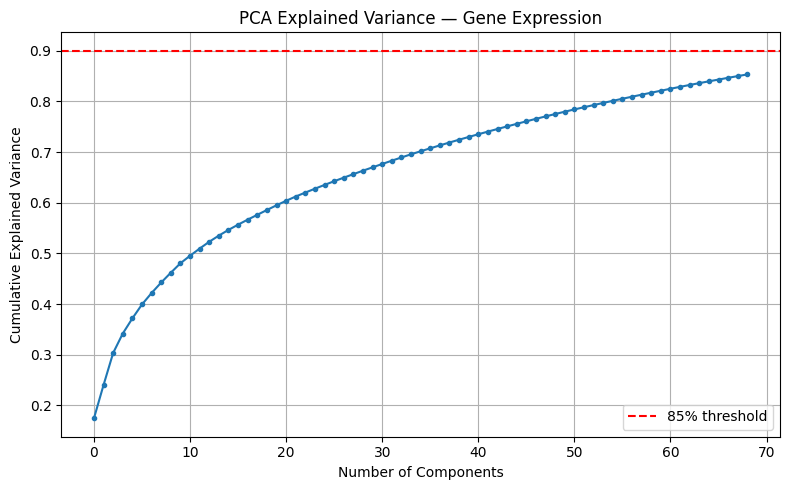

In [199]:
# Cumulative explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_vis.explained_variance_ratio_), marker="o", markersize=3)
plt.axhline(0.90, color="red", linestyle="--", label="85% threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance — Gene Expression")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

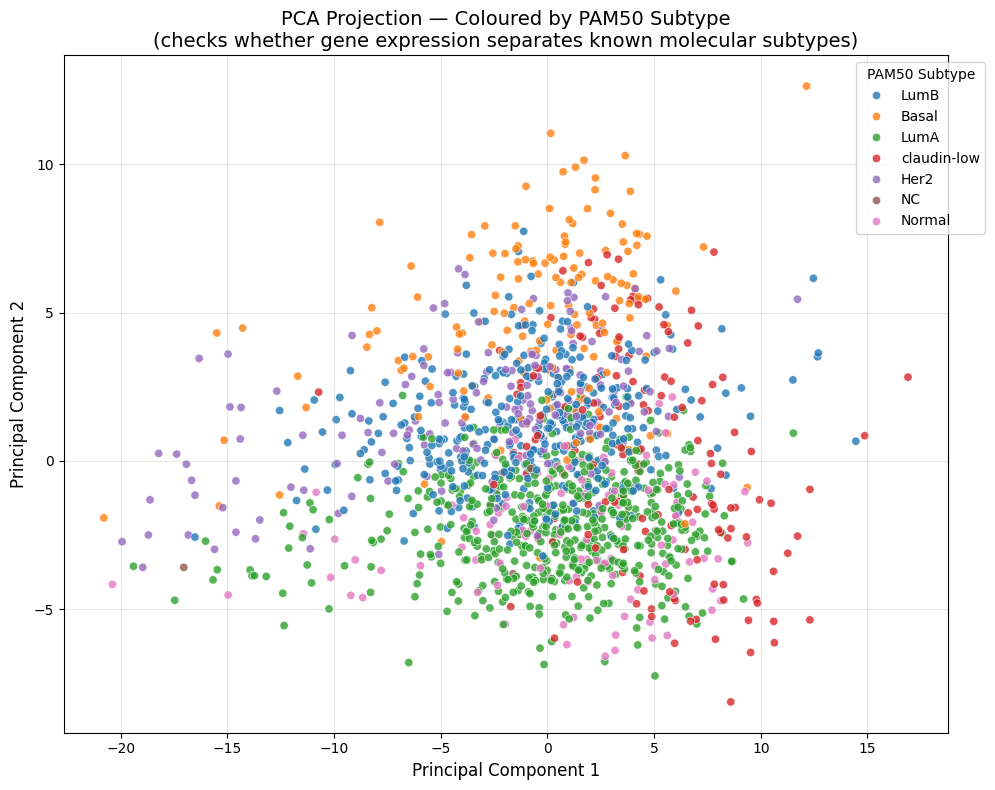

In [ ]:
#  PCA scatter colored based on PAM50 subtype 
pca_df = pd.DataFrame({
    "PC1": X_train_gene_pca[:, 0],
    "PC2": X_train_gene_pca[:, 1],
    "PAM50 Subtype": pam50_train.values
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="PAM50 Subtype", palette="tab10", alpha=0.8
)
plt.title("PCA Projection — Coloured by PAM50 Subtype\n(checks whether gene expression separates known molecular subtypes)", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), title="PAM50 Subtype")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

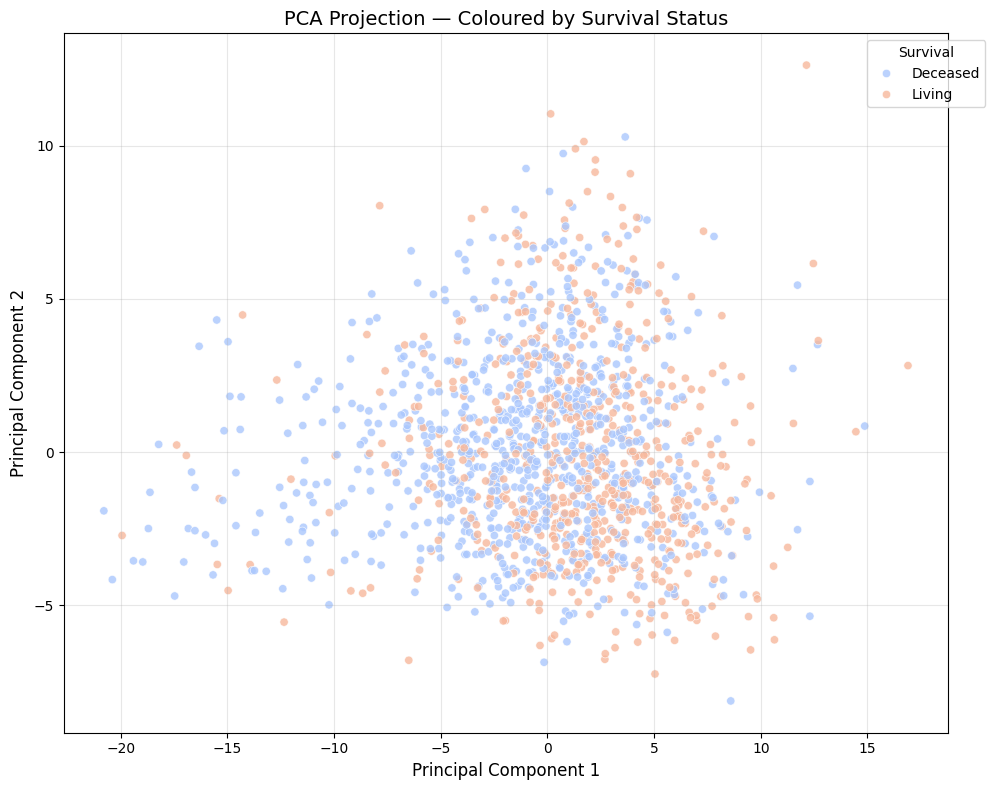

In [ ]:
#  PCA scatter coloured based on survival 
pca_df_surv = pd.DataFrame({
    "PC1": X_train_gene_pca[:, 0],
    "PC2": X_train_gene_pca[:, 1],
    "Survival": y_train.map({0: "Deceased", 1: "Living"}).values
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df_surv, x="PC1", y="PC2",
    hue="Survival", palette="coolwarm", alpha=0.8
)
plt.title("PCA Projection — Coloured by Survival Status", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), title="Survival")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Clustring gene expression**


The patients were clustered in this section according to their gene expression similarities. This was to investigate the survival behaviour of these transcriptomic subgroups.

In [ ]:
k_range = range(2, 11)
inertia_values = []
silhouette_values = []

# loop through different k values
for k in k_range:

    # KMeans
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # fit model
    cluster_labels = kmeans.fit_predict(X_train_gene)

    # store inertia for Elbow
    inertia_values.append(kmeans.inertia_)

    # Store silhouette score
    silhouette_values.append(silhouette_score(X_train_gene, cluster_labels))

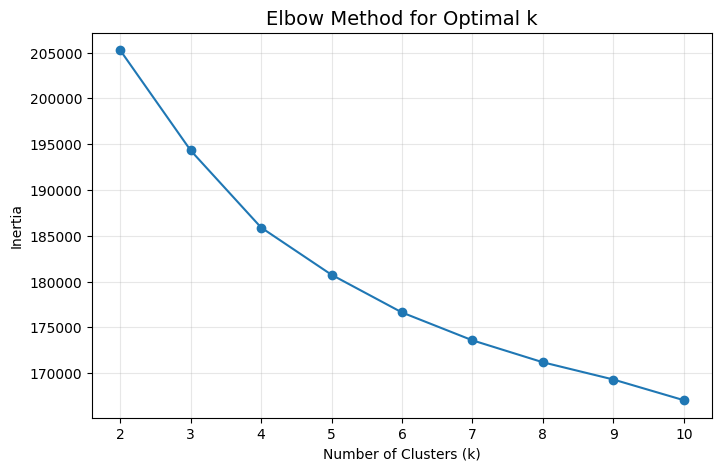

In [ ]:
# elbow plot
plt.figure(figsize=(8,5))
plt.plot(
    k_range,
    inertia_values,
    marker="o"
)
plt.title("Elbow Method for Optimal k",fontsize=14)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

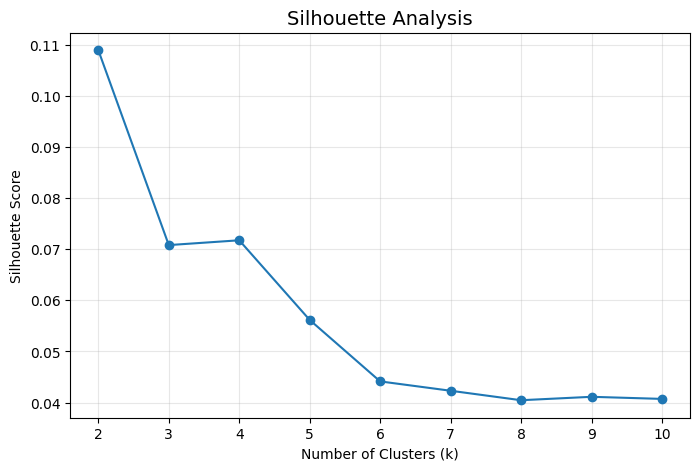

In [ ]:
# silhouette plit
plt.figure(figsize=(8,5))
plt.plot(
    k_range,
    silhouette_values,
    marker="o"
)
plt.title("Silhouette Analysis",fontsize=14)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# K-Means with 3 clusters  gene expression
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_gene)
test_clusters  = kmeans.predict(X_test_gene)

print("Training cluster sizes:")
unique, counts = np.unique(train_clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} patients")

Training cluster sizes:
  Cluster 0: 622 patients
  Cluster 1: 133 patients
  Cluster 2: 768 patients


/var/folders/3r/80rm85710xlfwfxk329qt65m0000gn/T/ipykernel_32745/2621595409.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=surv_by_cluster, x="Cluster", y="Survival Rate", palette="viridis")


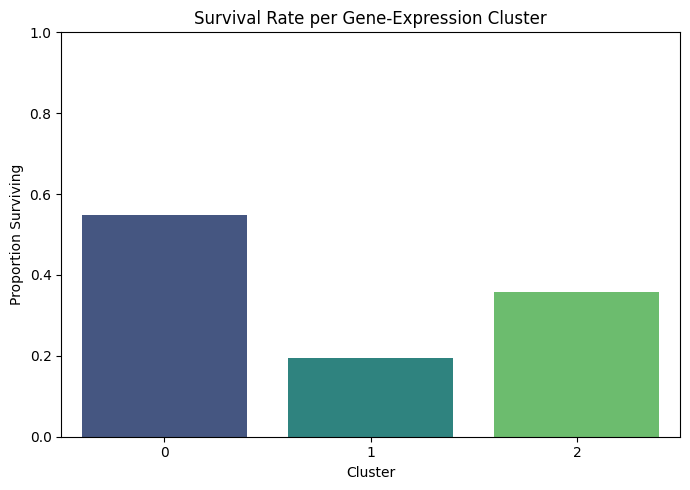

 Cluster  Survival Rate
       0       0.548232
       1       0.195489
       2       0.356771


In [134]:
# Survival rate per cluster
cluster_surv = pd.DataFrame({"Cluster": train_clusters, "Survival": y_train.values})
surv_by_cluster = cluster_surv.groupby("Cluster")["Survival"].mean().reset_index()
surv_by_cluster.columns = ["Cluster", "Survival Rate"]

plt.figure(figsize=(7, 5))
sns.barplot(data=surv_by_cluster, x="Cluster", y="Survival Rate", palette="viridis")
plt.title("Survival Rate per Gene-Expression Cluster")
plt.ylabel("Proportion Surviving")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
print(surv_by_cluster.to_string(index=False))

PAM50 subtype composition per cluster (row proportions):


PAM50,Basal,Her2,LumA,LumB,NC,Normal,claudin-low
Cluster,,,,,,,
0,0.095,0.059,0.394,0.127,0.000,0.100,0.225
1,0.158,0.316,0.271,0.165,0.008,0.075,0.008
2,0.104,0.122,0.342,0.357,0.004,0.049,0.021


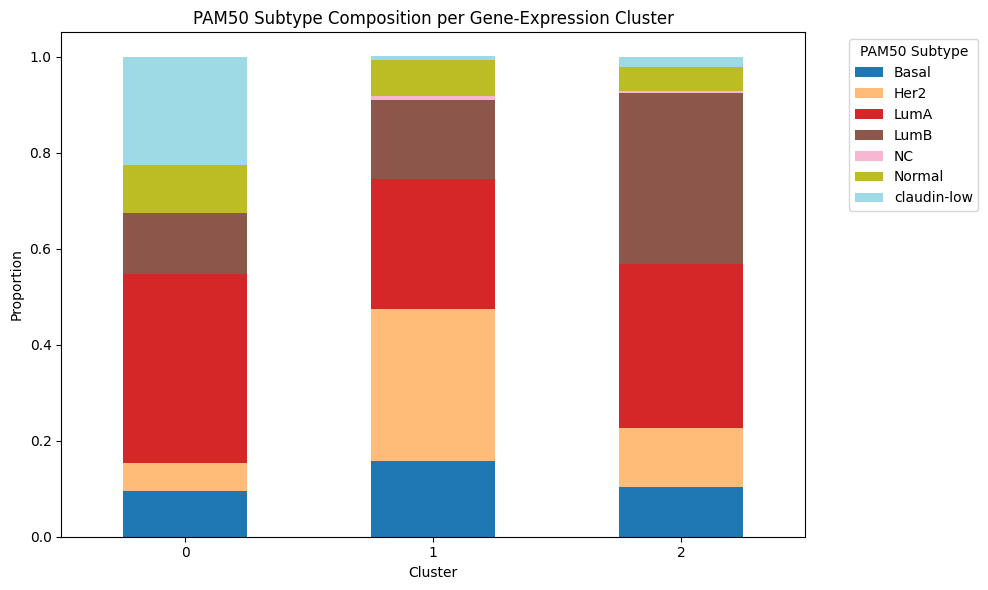

In [ ]:
# cluster vs PAM50 cross-tabulation 
pam50_train_reset = pam50_train.reset_index(drop=True)
cluster_pam50 = pd.DataFrame({"Cluster": train_clusters,"PAM50": pam50_train_reset.values})
ct = pd.crosstab(cluster_pam50["Cluster"], cluster_pam50["PAM50"], normalize="index").round(3)
print("PAM50 subtype composition per cluster (row proportions):")
display(ct)

ct.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("PAM50 Subtype Composition per Gene-Expression Cluster")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(title="PAM50 Subtype", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# **Helper Functions**

Here helper functions were developed to structure recurring tasks in the workflow. This rendered the code cleaner, shorter, and easier to replicate.

In [136]:
#Model training with grid search and cross validation
def train_model(model, param_grid, X_train, y_train, cv, scoring="f1", fit_params=None):

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    if fit_params:
        grid.fit(X_train, y_train, **fit_params)
    else:
        grid.fit(X_train, y_train)
    

    print("Best Parameters:")
    print(grid.best_params_)

    print("\nBest CV Score:")
    print(grid.best_score_)

    best_model = grid.best_estimator_

    return best_model, grid

In [ ]:
#model evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test, cv=None, model_name="Model"):

    # predictions
    y_pred = model.predict(X_test)

    # probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # test Results
    results = {

        "Model": model_name,

        "Accuracy":accuracy_score(y_test, y_pred),

        "Precision":precision_score(y_test, y_pred, zero_division=0),

        "Recall":recall_score(y_test, y_pred, zero_division=0),

        "F1 Score":f1_score(y_test, y_pred, zero_division=0),

        "ROC-AUC":roc_auc_score(y_test, y_prob)
    }

    # cross validation
    if cv is not None:

        scoring = {

            "accuracy": "accuracy",

            "precision": make_scorer(precision_score, zero_division=0),

            "recall": make_scorer(recall_score, zero_division=0),

            "f1": make_scorer(f1_score, zero_division=0),

            "roc_auc": "roc_auc"
        }

        cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
        
        results["CV Accuracy"] = cv_results["test_accuracy"].mean()
        results["CV Precision"] = cv_results["test_precision"].mean()
        results["CV Recall"] = cv_results["test_recall"].mean()
        results["CV F1"] = cv_results["test_f1"].mean()
        results["CV ROC-AUC"] = cv_results["test_roc_auc"].mean()
        
    # convert to dataframe
    results_df = pd.DataFrame([results])

    return y_pred, y_prob, results_df

In [ ]:
def visualize_results(

    y_test,

    model1_pred,
    model1_prob,
    model1_name,

    model2_pred,
    model2_prob,
    model2_name,

    model3_pred,
    model3_prob,
    model3_name,

    model4_pred,
    model4_prob,
    model4_name,


):

    # Confusion matrice
    fig, axes = plt.subplots(1, 4, figsize=(18,5))

    # Model 1
    sns.heatmap(
        confusion_matrix(y_test, model1_pred),
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0]
    )
    axes[0].set_title(model1_name)

    # Model 2
    sns.heatmap(
        confusion_matrix(y_test, model2_pred),
        annot=True,
        fmt="d",
        cmap="Greens",
        ax=axes[1]
    )
    axes[1].set_title(model2_name)
    
    # Model 3
    sns.heatmap(
        confusion_matrix(y_test, model3_pred),
        annot=True,
        fmt="d",
        cmap="Reds",
        ax=axes[2]
    )
    axes[2].set_title(model3_name)

    # Model 4
    sns.heatmap(
        confusion_matrix(y_test, model4_pred),
        annot=True,
        fmt="d",
        cmap="Oranges",
        ax=axes[3]
    )
    axes[3].set_title(model4_name)
    plt.tight_layout()
    plt.show()


    # ROC curves
    model1_fpr, model1_tpr, _ = roc_curve(y_test, model1_prob)
    model2_fpr, model2_tpr, _ = roc_curve(y_test, model2_prob)
    model3_fpr, model3_tpr, _ = roc_curve(y_test, model3_prob)
    model4_fpr, model4_tpr, _ = roc_curve(y_test, model4_prob)

    # plot ROC
    plt.figure(figsize=(8,6))

    plt.plot(model1_fpr, model1_tpr, label=f"{model1_name} AUC = {roc_auc_score(y_test, model1_prob):.3f}")
    plt.plot(model2_fpr, model2_tpr, label=f"{model2_name} AUC = {roc_auc_score(y_test, model2_prob):.3f}")
    plt.plot(model3_fpr, model3_tpr, label=f"{model3_name} AUC = {roc_auc_score(y_test, model3_prob):.3f}")
    plt.plot(model4_fpr, model4_tpr, label=f"{model4_name} AUC = {roc_auc_score(y_test, model4_prob):.3f}")
   
   # random baseline
    plt.plot([0,1], [0,1],  linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
#learning curve function
def plot_learning_curve(model, X, y, model_name, cv):

    train_sizes, train_scores, val_scores = learning_curve(estimator=model, X=X, y=y, cv=cv, scoring="f1", train_sizes=np.linspace(0.1, 1.0, 10),  n_jobs=-1)
    plt.figure(figsize=(7, 5))
    plt.plot( train_sizes, train_scores.mean(axis=1), marker="o", label="Training Score")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Score")
    plt.title(f"Learning Curve — {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# **Preparing for models**

The data and model settings have been prepared prior to training in this section. This made sure that all models went through the same training/evaluation process.

In [140]:
#Initializing Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [141]:
#decision tree parameters
dt_params = {
    "max_depth": [2, 4, 6], # Tree depth

    "min_samples_split": [2, 10, 20], # Split control

    "min_samples_leaf": [1, 5, 10], # Leaf control

    "ccp_alpha": [0.0, 0.001, 0.01], # pruning
    
    "criterion": ["gini", "entropy"] # Spliting stratagy
}

In [142]:
#XGBoost parameters
xgb_params = {

    "n_estimators": [100, 200], # num of trees
    
    "max_depth": [2, 4], # tree complixity
    
    "learning_rate": [0.01, 0.05], # learning rate

    "subsample": [0.6, 0.8], # sampling

    "reg_alpha": [0, 1], # l1 regularization

    "reg_lambda": [1, 5] # l2 regularization
}

In [ ]:
# Logistic Regression parameters
lr_params = {

    "C": [0.01, 0.1, 1, 10], # regularization strength

    "solver": ["liblinear"], # supports l1 and l2

    "class_weight": ["balanced"], # handles class imbalance

    "max_iter": [1000] # ensures convergence
}

In [144]:
# ebm parameters
ebm_params = {

    "learning_rate": [0.005, 0.05], # learning rate
    
    "max_rounds": [50, 300], # boosting rounds

    "max_leaves": [2, 5], # tree complexity

    "max_bins": [64, 256], # binning

    "interactions": [0, 10] # interactions
}

# **Predecting survival based on the 3 clustrs**

In this section, we built the survival prediction models individually for each cluster of genes expression. This was to determine if there were distinct patterns of survival prediction across these different transcriptomic groups.

In [ ]:
# creating lists to Store probabilities for late fusion
cluster_dt_train_probs = np.zeros((X_train_gene.shape[0], 3))
cluster_dt_test_probs = np.zeros((X_test_gene.shape[0], 3))

cluster_lr_train_probs = np.zeros((X_train_gene.shape[0], 3))
cluster_lr_test_probs = np.zeros((X_test_gene.shape[0], 3))

cluster_xgb_train_probs = np.zeros((X_train_gene.shape[0], 3))
cluster_xgb_test_probs = np.zeros((X_test_gene.shape[0], 3))

cluster_ebm_train_probs = np.zeros((X_train_gene.shape[0], 3))
cluster_ebm_test_probs = np.zeros((X_test_gene.shape[0], 3))


Cluster 0
Train samples: 622, Test samples: 133
Survival rate (train): 0.55
Desicion Tree
Best Parameters:
{'ccp_alpha': 0.01, 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best CV Score:
0.6157838127651013
XGBoost
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 0.6}

Best CV Score:
0.6435048798453458
Logistic Regression
Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}

Best CV Score:
0.6252494378485823
EBM
Best Parameters:
{'interactions': 0, 'learning_rate': 0.005, 'max_bins': 64, 'max_leaves': 2, 'max_rounds': 50}

Best CV Score:
0.5890111079456851


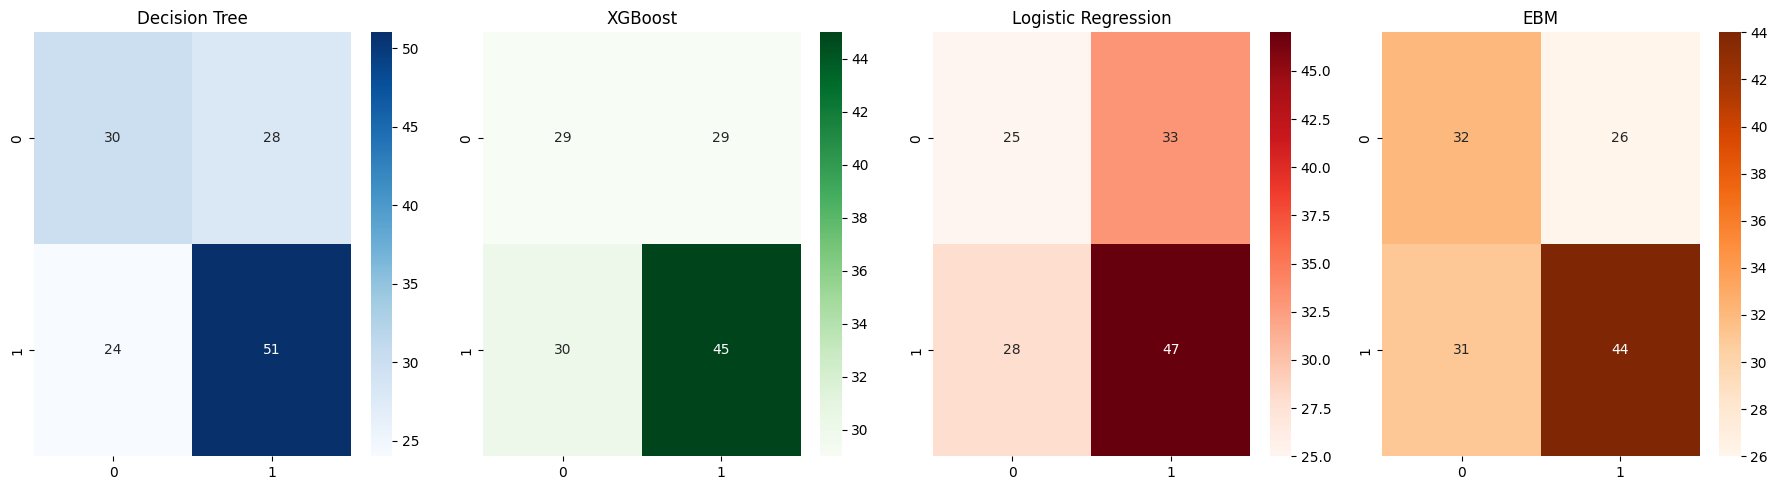

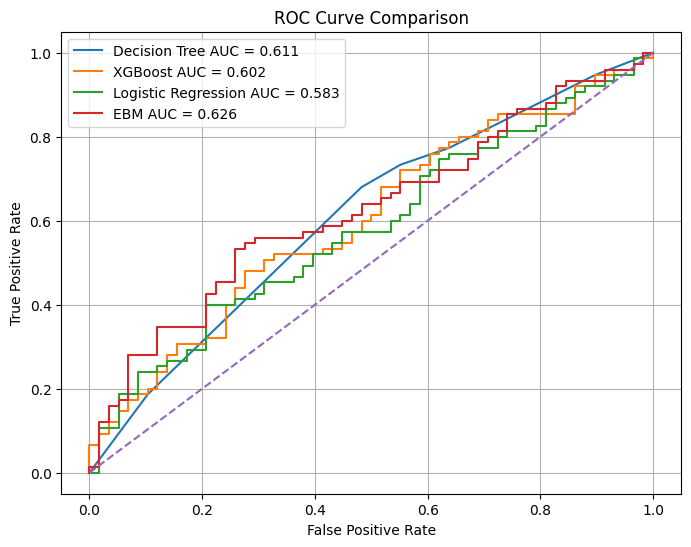


Cluster 1
Train samples: 133, Test samples: 37
Survival rate (train): 0.20
Desicion Tree
Best Parameters:
{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best CV Score:
0.35705882352941176
XGBoost
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}

Best CV Score:
0.28253968253968254
Logistic Regression
Best Parameters:
{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}

Best CV Score:
0.33095238095238094
EBM
Best Parameters:
{'interactions': 10, 'learning_rate': 0.005, 'max_bins': 256, 'max_leaves': 2, 'max_rounds': 50}

Best CV Score:
0.31256731140100913


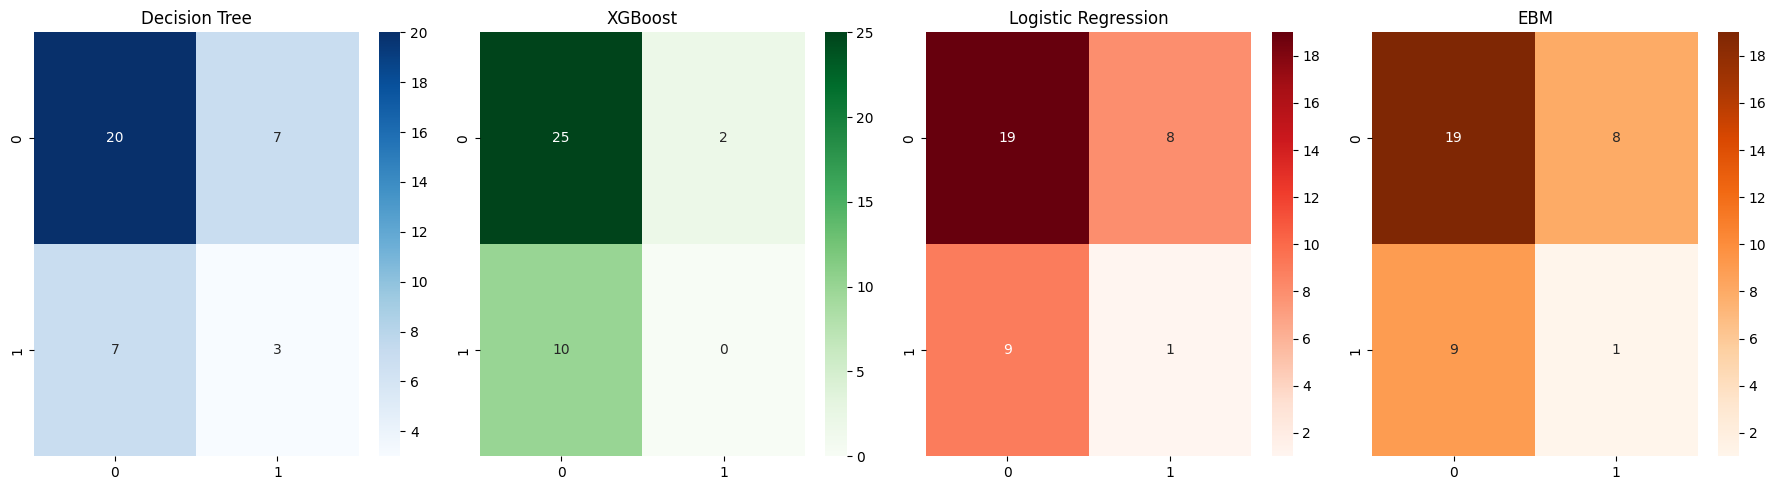

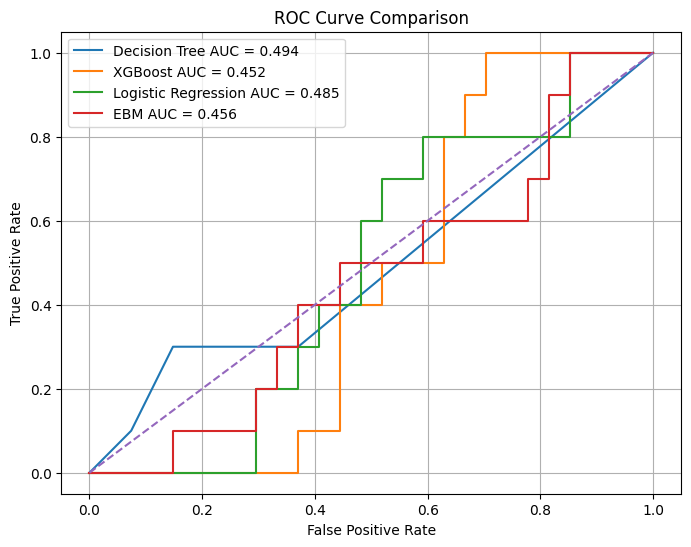


Cluster 2
Train samples: 768, Test samples: 211
Survival rate (train): 0.36
Desicion Tree
Best Parameters:
{'ccp_alpha': 0.01, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best CV Score:
0.46080288630060784
XGBoost
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}

Best CV Score:
0.49566463359247087
Logistic Regression
Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}

Best CV Score:
0.4826837447835284
EBM
Best Parameters:
{'interactions': 0, 'learning_rate': 0.005, 'max_bins': 64, 'max_leaves': 2, 'max_rounds': 300}

Best CV Score:
0.5883418023161002


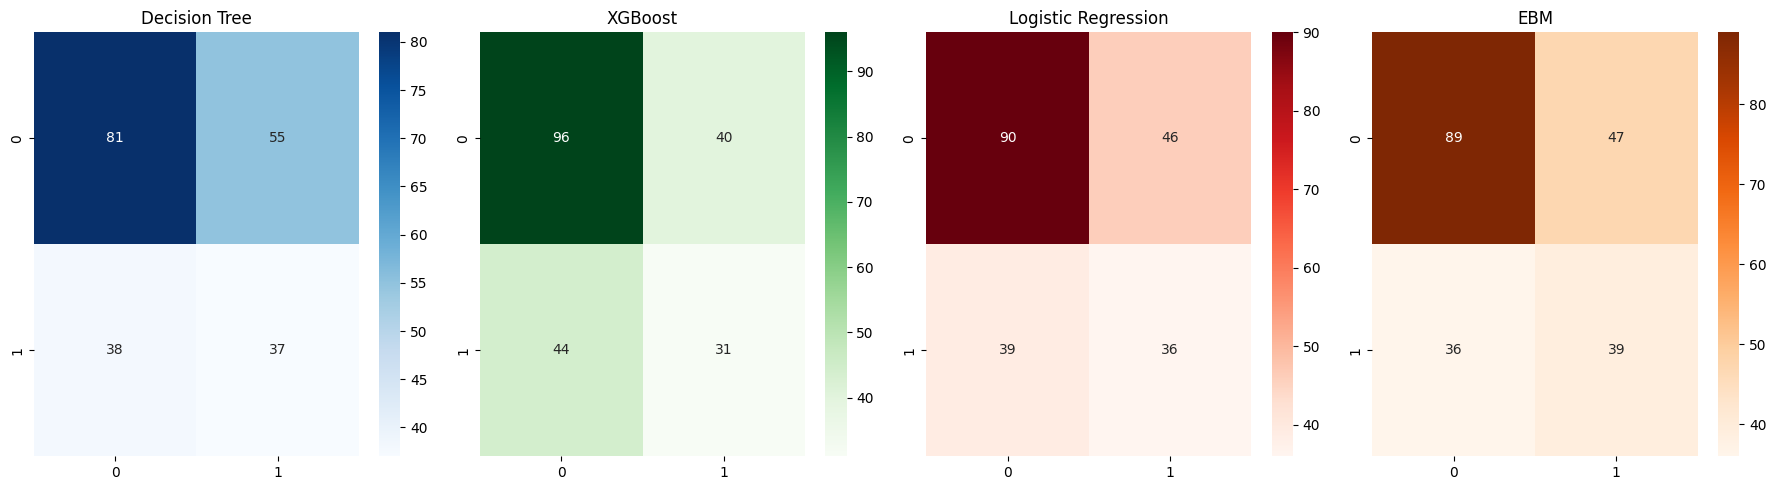

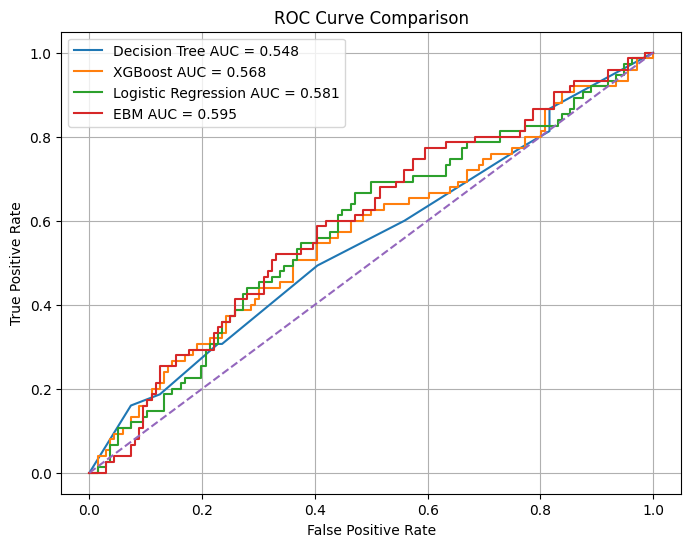

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Cluster
0,Decision Tree,0.609023,0.645570,0.680000,0.662338,0.610805,0.556387,0.585262,0.657161,0.615784,0.559204,0
1,XGBoost,0.556391,0.608108,0.600000,0.604027,0.602299,0.602929,0.634021,0.653964,0.643505,0.602992,0
2,Logistic Regression,0.541353,0.587500,0.626667,0.606452,0.582529,0.574013,0.604039,0.648082,0.625249,0.600945,0
3,EBM,0.571429,0.628571,0.586667,0.606897,0.625977,0.562839,0.569280,0.830179,0.674349,0.609439,0
4,Decision Tree,0.621622,0.300000,0.300000,0.300000,0.494444,0.653276,0.298442,0.466667,0.357059,0.612222,1
5,XGBoost,0.675676,0.000000,0.000000,0.000000,0.451852,0.789744,0.550000,0.200000,0.282540,0.512900,1
6,Logistic Regression,0.540541,0.111111,0.100000,0.105263,0.485185,0.722507,0.360000,0.333333,0.330952,0.548139,1
7,EBM,0.540541,0.111111,0.100000,0.105263,0.455556,0.804558,0.000000,0.000000,0.000000,0.450476,1
8,Decision Tree,0.559242,0.402174,0.493333,0.443114,0.548284,0.506544,0.379690,0.597980,0.460803,0.540575,2
9,XGBoost,0.601896,0.436620,0.413333,0.424658,0.567843,0.635337,0.490137,0.506869,0.495665,0.646166,2


In [ ]:
# Store results
cluster_metrics = []
# loop thtough the clusters
for cluster_id in range(3):

    print(f"\nCluster {cluster_id}")

    # Select cluster samples
    train_mask = train_clusters == cluster_id
    test_mask = test_clusters == cluster_id

    Xc_train = X_train_gene[train_mask]
    yc_train = y_train.values[train_mask]

    Xc_test = X_test_gene[test_mask]
    yc_test = y_test.values[test_mask]

    # Per-cluster class ratio for XGBoost
    n_neg = (yc_train == 0).sum()
    n_pos = (yc_train == 1).sum()
    spw   = round(n_neg / n_pos, 2) if n_pos > 0 else 1.0

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=yc_train
    )
    print(f"Train samples: {len(yc_train)}, "f"Test samples: {len(yc_test)}")
    print(f"Survival rate (train): "f"{yc_train.mean():.2f}")

    # Desicion Tree
    print("Desicion Tree")
    dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42) 
    best_dt, dt_grid = train_model(model=dt_model, param_grid=dt_params, X_train=Xc_train, y_train=yc_train, cv=cv) #Training
    dt_pred, dt_prob, dt_results = evaluate_model(model=best_dt, X_train=Xc_train, X_test=Xc_test, y_train=yc_train, y_test=yc_test, cv=cv, model_name="Decision Tree") #Evaluation
    dt_prob_train = best_dt.predict_proba(Xc_train)[:,1] #prediction probabilities

    # XGBoost
    print("XGBoost")
    xgb_model = XGBClassifier(scale_pos_weight = spw,eval_metric="logloss",random_state=42)
    best_xgb, xgb_grid = train_model( model=xgb_model, param_grid=xgb_params, X_train=Xc_train, y_train=yc_train, cv=cv) #Training
    xgb_pred, xgb_prob, xgb_results = evaluate_model(model=best_xgb, X_train=Xc_train, X_test=Xc_test, y_train=yc_train, y_test=yc_test, cv=cv, model_name="XGBoost") #Evaluation
    xgb_prob_train = best_xgb.predict_proba(Xc_train)[:,1]#prediction probabilities

    # Logistic Regression
    print("Logistic Regression") 
    lr_model = LogisticRegression(random_state=42)
    best_lr, lr_grid = train_model(model=lr_model, param_grid=lr_params, X_train=Xc_train, y_train=yc_train, cv=cv) #Training
    lr_pred, lr_prob, lr_results = evaluate_model(model=best_lr, X_train=Xc_train, X_test=Xc_test, y_train=yc_train, y_test=yc_test, cv=cv, model_name="Logistic Regression") #Evaluation
    lr_prob_train = best_lr.predict_proba(Xc_train)[:,1] #prediction probabilities

    # EBM
    print("EBM")
    ebm_model = ExplainableBoostingClassifier(random_state=42)
    best_ebm, ebm_grid = train_model(model=ebm_model, param_grid=ebm_params, X_train=Xc_train, y_train=yc_train, cv=cv, fit_params={"sample_weight": sample_weights} )#Training
    ebm_pred, ebm_prob, ebm_results = evaluate_model(model=best_ebm, X_train=Xc_train, X_test=Xc_test, y_train=yc_train, y_test=yc_test, cv=cv, model_name="EBM") #Evaluation
    ebm_prob_train = best_ebm.predict_proba(Xc_train)[:,1]#prediction probabilities

    # Store probabilities for late fusion
    cluster_dt_train_probs[train_mask, cluster_id] = dt_prob_train
    cluster_dt_test_probs[test_mask, cluster_id] = dt_prob

    cluster_lr_train_probs[train_mask, cluster_id] = lr_prob_train
    cluster_lr_test_probs[test_mask, cluster_id] = lr_prob

    cluster_xgb_train_probs[train_mask, cluster_id] = xgb_prob_train
    cluster_xgb_test_probs[test_mask, cluster_id] = xgb_prob

    cluster_ebm_train_probs[train_mask, cluster_id] = ebm_prob_train
    cluster_ebm_test_probs[test_mask, cluster_id] = ebm_prob 

    # Cluster num column
    dt_results["Cluster"] = cluster_id
    xgb_results["Cluster"] = cluster_id
    lr_results["Cluster"] = cluster_id
    ebm_results["Cluster"] = cluster_id

    # Save results
    cluster_metrics.append(dt_results)
    cluster_metrics.append(xgb_results)
    cluster_metrics.append(lr_results)
    cluster_metrics.append(ebm_results)

    # Visulization
    visualize_results(

        y_test=yc_test,

        model1_pred=dt_pred,
        model1_prob=dt_prob,
        model1_name="Decision Tree",

        model2_pred=xgb_pred,
        model2_prob=xgb_prob,
        model2_name="XGBoost",
        
        model3_pred=lr_pred,
        model3_prob=lr_prob,
        model3_name="Logistic Regression",

        model4_pred=ebm_pred,
        model4_prob=ebm_prob,
        model4_name="EBM"



    )


# Final results table
final_cluster_results = pd.concat( cluster_metrics, ignore_index=True)
final_cluster_results

# **using clinical data for predicting survival**

In this section clinical data alone was used to train the survival prediction models. This enabled the comparison of clinical information with prediction based on the clusterd gene expressions

In [154]:
#Decision Tree
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
best_dt_clin, dt_grid = train_model(model=dt_model, param_grid=dt_params, X_train=X_train_clinical, y_train=y_train, cv=cv)
dt_clin_pred, dt_clin_prob, dt_clin_results = evaluate_model(model=best_dt_clin, X_train=X_train_clinical, X_test=X_test_clinical, y_train=y_train, y_test=y_test, cv=cv, model_name="Decision Tree")

Best Parameters:
{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best CV Score:
0.7189116187674524


In [155]:
#XGBoost
xgb_model = XGBClassifier(eval_metric="logloss", random_state=42)
best_xgb_clin, xgb_grid = train_model(model=xgb_model, param_grid=xgb_params, X_train=X_train_clinical, y_train=y_train, cv=cv)
xgb_clin_pred, xgb_clin_prob, xgb_clin_results = evaluate_model(model=best_xgb_clin, X_train=X_train_clinical, X_test=X_test_clinical, y_train=y_train, y_test=y_test, cv=cv, model_name="XGBoost")


Best Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 5, 'subsample': 0.8}

Best CV Score:
0.7393520003627453


In [156]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42)
best_lr_clin, lr_grid = train_model(model=lr_model, param_grid=lr_params, X_train=X_train_clinical, y_train=y_train, cv=cv)
lr_clin_pred, lr_clin_prob, lr_clin_results = evaluate_model(model=best_lr_clin, X_train=X_train_clinical, X_test=X_test_clinical, y_train=y_train, y_test=y_test, cv=cv, model_name="Logistic Regression")

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}

Best CV Score:
0.709083271419156


In [157]:
# EBM
ebm_model = ExplainableBoostingClassifier(random_state=42)
best_ebm_clin, ebm_grid = train_model(model=ebm_model, param_grid=ebm_params, X_train=X_train_clinical, y_train=y_train, cv=cv)
ebm_clin_pred, ebm_clin_prob, ebm_clin_results = evaluate_model(model=best_ebm_clin, X_train=X_train_clinical, X_test=X_test_clinical, y_train=y_train, y_test=y_test, cv=cv, model_name="EBM")

Best Parameters:
{'interactions': 10, 'learning_rate': 0.005, 'max_bins': 64, 'max_leaves': 5, 'max_rounds': 300}

Best CV Score:
0.7405834050489578


In [158]:
#Store porbabilites for late fusion
dt_clin_train_prob = best_dt_clin.predict_proba(X_train_clinical)[:,1]
dt_clin_test_prob = dt_clin_prob

xgb_clin_train_prob = best_xgb_clin.predict_proba(X_train_clinical)[:,1]
xgb_clin_test_prob = xgb_clin_prob

lr_clin_train_prob = best_lr_clin.predict_proba(X_train_clinical)[:,1]
lr_clin_test_prob = lr_clin_prob

ebm_clin_train_prob = best_ebm_clin.predict_proba(X_train_clinical)[:,1]
ebm_clin_test_prob = ebm_clin_prob

In [159]:
# results table
clinical_eval = pd.concat([dt_clin_results, xgb_clin_results, lr_clin_results, ebm_clin_results], ignore_index=True)
clinical_eval

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Decision Tree,0.727034,0.660920,0.71875,0.688623,0.804468,0.741956,0.664680,0.787742,0.718912,0.807335
1,XGBoost,0.782152,0.773050,0.68125,0.724252,0.883654,0.782657,0.746471,0.733176,0.739352,0.850052
2,Logistic Regression,0.727034,0.660920,0.71875,0.688623,0.798162,0.739989,0.669682,0.753488,0.709083,0.799764
3,EBM,0.792651,0.787234,0.69375,0.737542,0.866714,0.782662,0.745484,0.736325,0.740583,0.851568


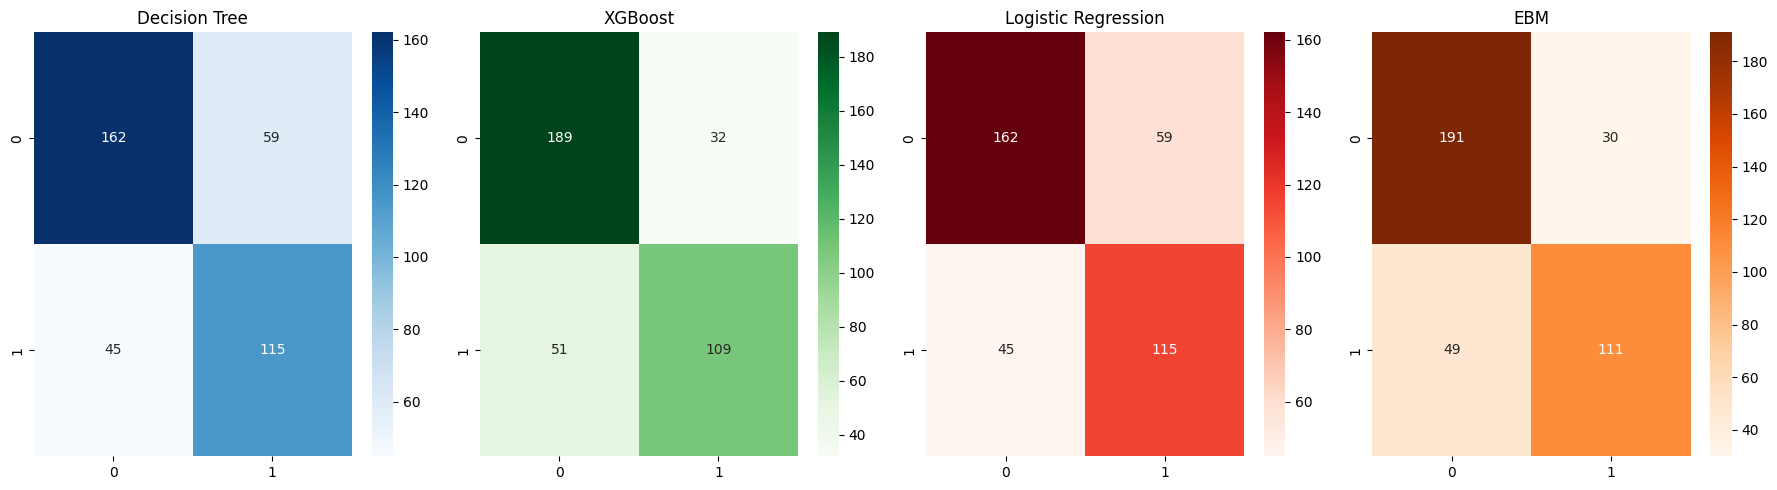

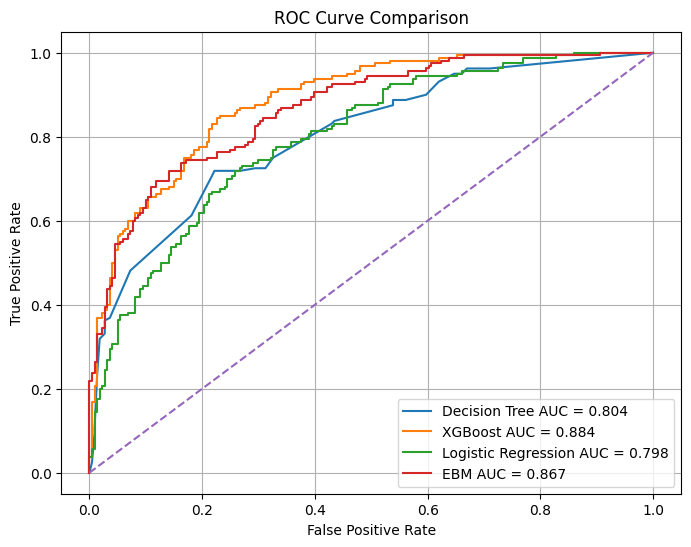

In [160]:
# Visualization
visualize_results(

    y_test=y_test,

    model1_pred=dt_clin_pred,
    model1_prob=dt_clin_prob,
    model1_name="Decision Tree",

    model2_pred=xgb_clin_pred,
    model2_prob=xgb_clin_prob,
    model2_name="XGBoost",

    model3_pred=lr_clin_pred,
    model3_prob=lr_clin_prob,
    model3_name="Logistic Regression",

    model4_pred=ebm_clin_pred,
    model4_prob=ebm_clin_prob,
    model4_name="EBM"
)

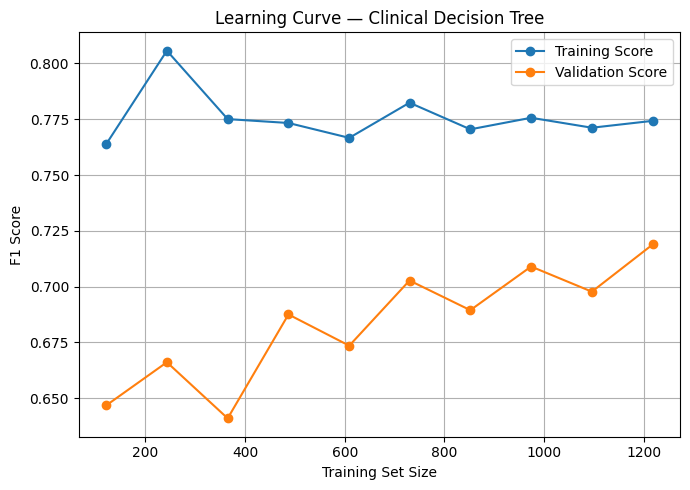

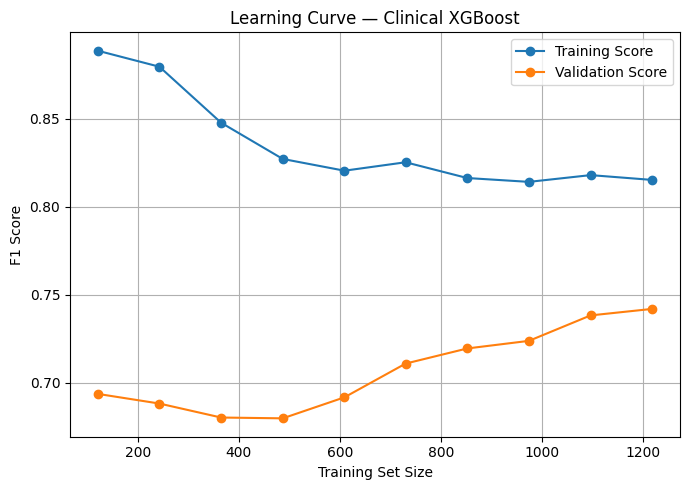

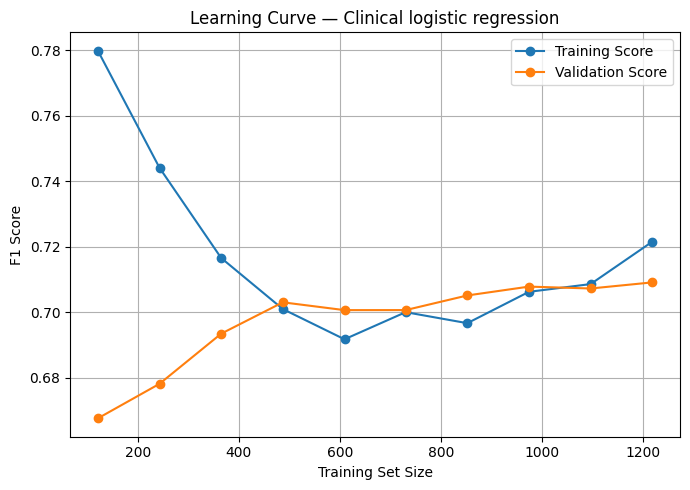

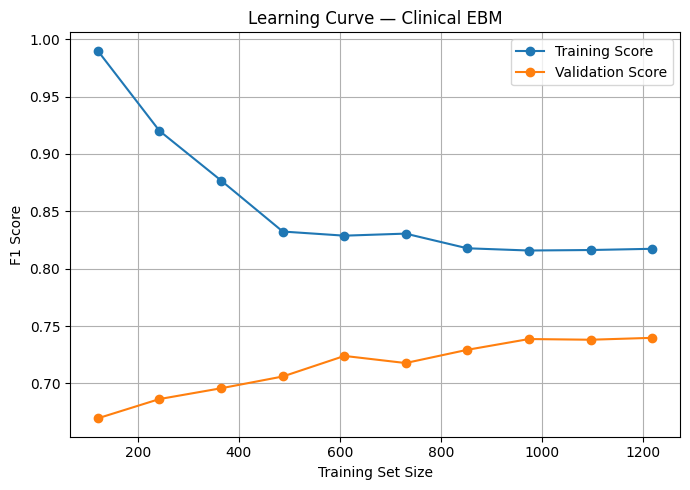

In [ ]:
#learning curves 
plot_learning_curve(model=best_dt_clin, X=X_train_clinical, y=y_train, model_name="Clinical Decision Tree", cv=cv)

plot_learning_curve(model=best_xgb_clin, X=X_train_clinical, y=y_train, model_name="Clinical XGBoost", cv=cv)

plot_learning_curve(model=best_lr_clin, X=X_train_clinical, y=y_train, model_name="Clinical logistic regression", cv=cv)

plot_learning_curve(model=best_ebm_clin, X=X_train_clinical, y=y_train, model_name="Clinical EBM", cv=cv)

# **Combine late fusion**

The prediction probability obtained from clinical and cluster-based models were merged in this section. This tested the possibility of improving the prediction of survival by combining both sources of information.

In [ ]:
meta_X_train_xgb = pd.DataFrame({"clinical_xgb": xgb_clin_train_prob})
meta_X_test_xgb = pd.DataFrame({"clinical_xgb": xgb_clin_test_prob})

# add xgboost probabilities from each cluster
for i in range(3):

    meta_X_train_xgb[f"xgb_cluster_{i}"] = cluster_xgb_train_probs[:, i]
    meta_X_test_xgb[f"xgb_cluster_{i}"] = cluster_xgb_test_probs[:, i]


In [ ]:
meta_X_train_dt = pd.DataFrame({"clinical_dt": dt_clin_train_prob})
meta_X_test_dt = pd.DataFrame({"clinical_dt": dt_clin_test_prob})

# add Decision Tree probabilities from each cluster
for i in range(3):

    meta_X_train_dt[f"dt_cluster_{i}"] = cluster_dt_train_probs[:, i]

    meta_X_test_dt[f"dt_cluster_{i}"] = cluster_dt_test_probs[:, i]

In [ ]:
meta_X_train_lr = pd.DataFrame({"clinical_lr": lr_clin_train_prob})
meta_X_test_lr = pd.DataFrame({"clinical_lr": lr_clin_test_prob})

# add logistic regression probabilities from each cluster
for i in range(3):

    meta_X_train_lr[f"lr_cluster_{i}"] = cluster_lr_train_probs[:, i]
    meta_X_test_lr[f"lr_cluster_{i}"] = cluster_lr_test_probs[:, i]


In [ ]:
meta_X_train_ebm = pd.DataFrame({"clinical_ebm": ebm_clin_train_prob})
meta_X_test_ebm = pd.DataFrame({"clinical_ebm": ebm_clin_test_prob})

# add ebm probabilities from each cluster
for i in range(3):

    meta_X_train_ebm[f"ebm_cluster_{i}"] = cluster_ebm_train_probs[:, i]
    meta_X_test_ebm[f"ebm_cluster_{i}"] = cluster_ebm_test_probs[:, i]

In [169]:
#Desicion Tree
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
best_dt_meta, dt_grid = train_model(model=dt_model, param_grid=dt_params, X_train=meta_X_train_dt, y_train=y_train, cv=cv)
dt_meta_pred, dt_meta_prob, dt_meta_results = evaluate_model(model=best_dt_meta, X_train=meta_X_train_dt, X_test=meta_X_test_dt, y_train=y_train, y_test=y_test, cv=cv, model_name="Decision Tree Meta")

Best Parameters:
{'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best CV Score:
0.785119847210064


In [170]:
# XGBoost
xgb_model = XGBClassifier(eval_metric="logloss", random_state=42)
best_xgb_meta, xgb_grid = train_model(model=xgb_model, param_grid=xgb_params, X_train=meta_X_train_xgb, y_train=y_train, cv=cv)
xgb_meta_pred, xgb_meta_prob, xgb_meta_results = evaluate_model(model=best_xgb_meta, X_train=meta_X_train_xgb, X_test=meta_X_test_xgb, y_train=y_train, y_test=y_test, cv=cv, model_name="XGBoost Meta")

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}

Best CV Score:
0.9412389831950148


In [171]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42)
best_lr_meta, lr_grid = train_model(model=lr_model, param_grid=lr_params, X_train=meta_X_train_lr, y_train=y_train, cv=cv)
lr_meta_pred, lr_meta_prob, lr_meta_results = evaluate_model(model=best_lr_meta, X_train=meta_X_train_lr, X_test=meta_X_test_lr, y_train=y_train, y_test=y_test, cv=cv, model_name="Logistic Regression Meta")

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}

Best CV Score:
0.7794474026002673


In [172]:
# EBM
ebm_model = ExplainableBoostingClassifier(random_state=42)
best_ebm_meta, ebm_grid = train_model(model=ebm_model, param_grid=ebm_params, X_train=meta_X_train_ebm, y_train=y_train, cv=cv)
ebm_meta_pred, ebm_meta_prob, ebm_meta_results = evaluate_model(model=best_ebm_meta, X_train=meta_X_train_ebm, X_test=meta_X_test_ebm, y_train=y_train, y_test=y_test, cv=cv, model_name="EBM Meta")

Best Parameters:
{'interactions': 10, 'learning_rate': 0.05, 'max_bins': 64, 'max_leaves': 5, 'max_rounds': 300}

Best CV Score:
0.8575015353753184


In [173]:
#Results Table
meta_eval = pd.concat([dt_meta_results, xgb_meta_results, lr_meta_results, ebm_meta_results], ignore_index=True)
meta_eval


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Decision Tree Meta,0.708661,0.676259,0.58750,0.628763,0.779426,0.814847,0.769723,0.804942,0.785120,0.892533
1,XGBoost Meta,0.682415,0.666667,0.48750,0.563177,0.764734,0.951406,0.955998,0.928173,0.941239,0.987173
2,Logistic Regression Meta,0.711286,0.647059,0.68750,0.666667,0.774038,0.807616,0.751135,0.811156,0.779447,0.881401
3,EBM Meta,0.771654,0.766423,0.65625,0.707071,0.820588,0.879834,0.856473,0.859557,0.857502,0.943616


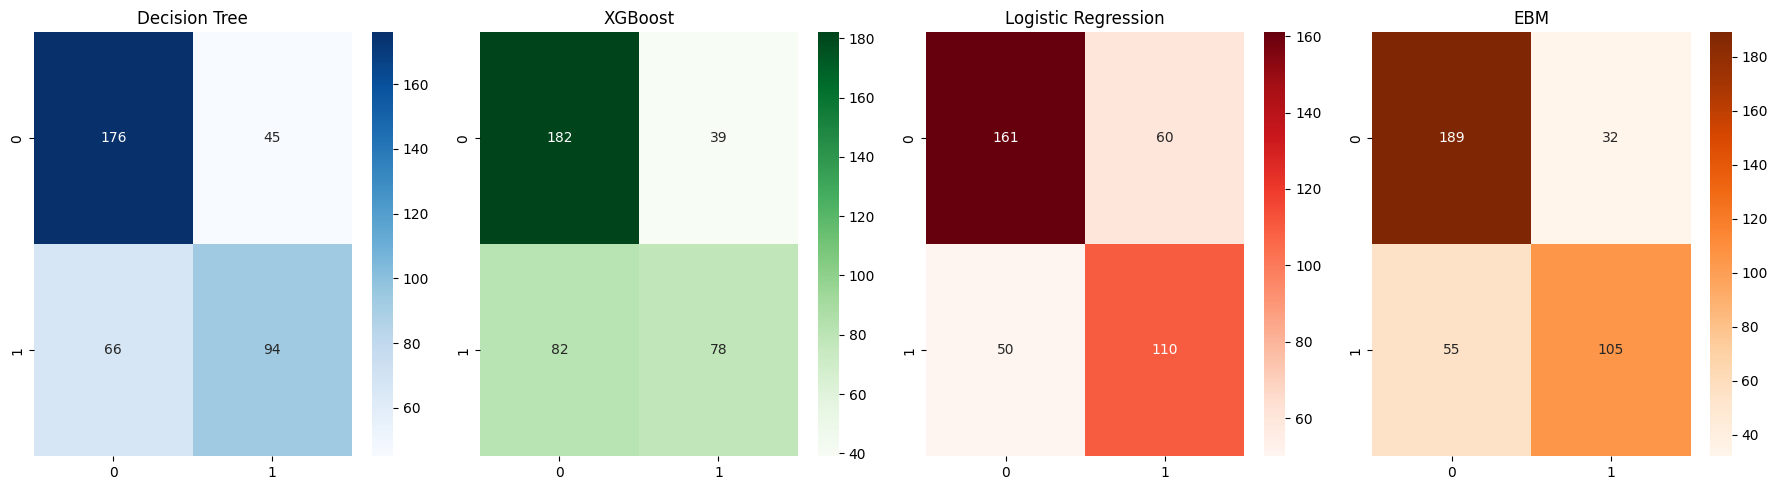

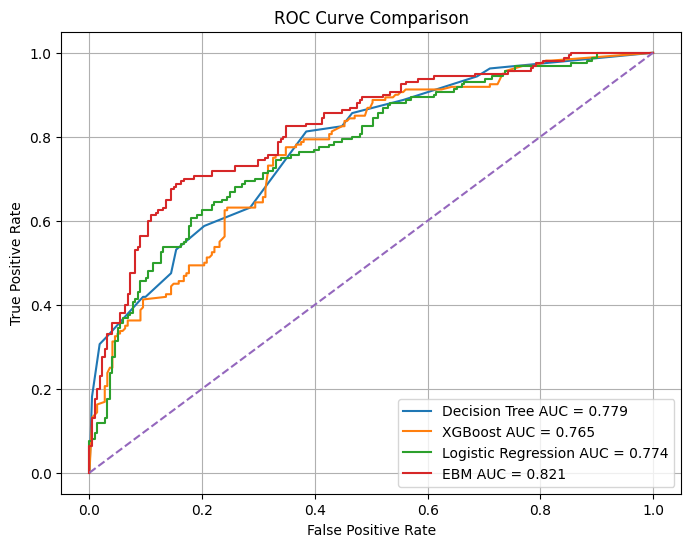

In [174]:
#Visualization
visualize_results(

    y_test=y_test,

    model1_pred=dt_meta_pred,
    model1_prob=dt_meta_prob,
    model1_name="Decision Tree",

    model2_pred=xgb_meta_pred,
    model2_prob=xgb_meta_prob,
    model2_name="XGBoost",

    model3_pred=lr_meta_pred,
    model3_prob=lr_meta_prob,
    model3_name="Logistic Regression",

    model4_pred=ebm_meta_pred,
    model4_prob=ebm_meta_prob,
    model4_name="EBM"
)

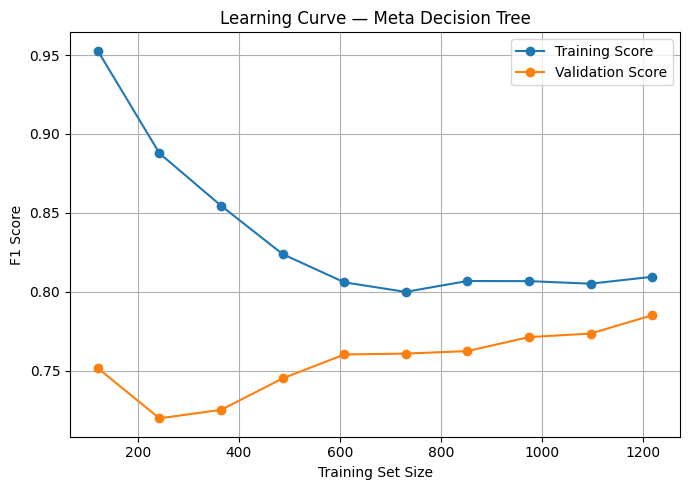

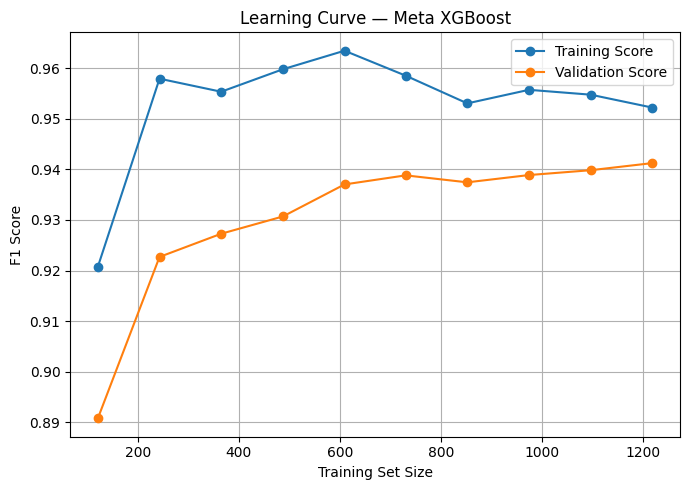

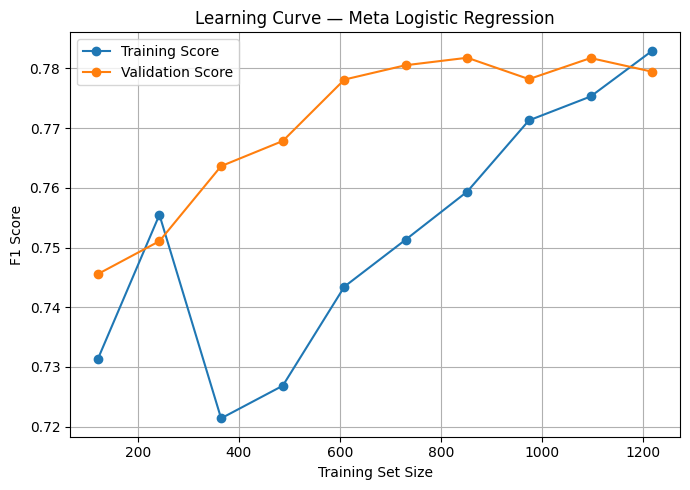

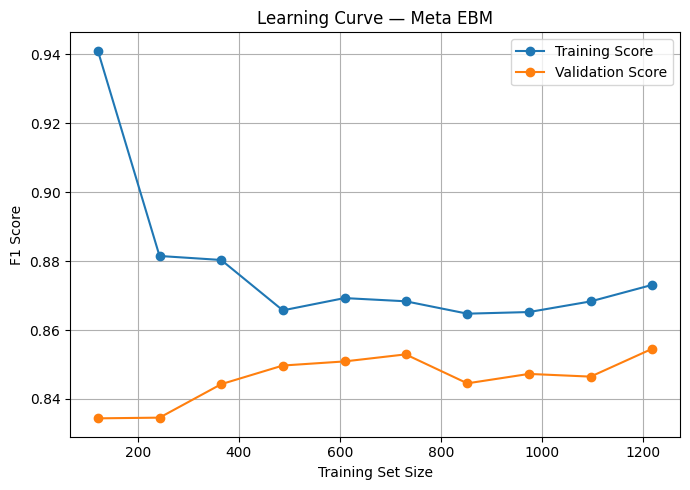

In [ ]:
#learning curves
plot_learning_curve(model=best_dt_meta, X=meta_X_train_dt, y=y_train, model_name="Meta Decision Tree", cv=cv)

plot_learning_curve(model=best_xgb_meta, X=meta_X_train_xgb, y=y_train, model_name="Meta XGBoost", cv=cv)

plot_learning_curve(model=best_lr_meta, X=meta_X_train_lr, y=y_train, model_name="Meta Logistic Regression", cv=cv)

plot_learning_curve(model=best_ebm_meta, X=meta_X_train_ebm, y=y_train, model_name="Meta EBM", cv=cv)

# **summary**

The output of the various models has been gathered in this section and compared. This helped to determine the most effective and trustworthy model in a clear way.

In [ ]:
# Add source labels
clinical_eval["Source"] = "Clinical"
final_cluster_results["Source"] = "Cluster"
meta_eval["Source"] = "Late Fusion"
meta_eval["Model"] = meta_eval["Model"].str.replace(" Meta", "")

#merge all the results
all_results = pd.concat([clinical_eval, final_cluster_results, meta_eval], ignore_index=True)
all_results = all_results[["Source", "Cluster", "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "CV Accuracy", "CV Precision", "CV Recall", "CV F1", "CV ROC-AUC"]]
all_results

,Source,Cluster,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Clinical,NaN,Decision Tree,0.727034,0.660920,0.718750,0.688623,0.804468,0.741956,0.664680,0.787742,0.718912,0.807335
1,Clinical,NaN,XGBoost,0.782152,0.773050,0.681250,0.724252,0.883654,0.782657,0.746471,0.733176,0.739352,0.850052
2,Clinical,NaN,Logistic Regression,0.727034,0.660920,0.718750,0.688623,0.798162,0.739989,0.669682,0.753488,0.709083,0.799764
3,Clinical,NaN,EBM,0.792651,0.787234,0.693750,0.737542,0.866714,0.782662,0.745484,0.736325,0.740583,0.851568
4,Cluster,0.0,Decision Tree,0.609023,0.645570,0.680000,0.662338,0.610805,0.556387,0.585262,0.657161,0.615784,0.559204
5,Cluster,0.0,XGBoost,0.556391,0.608108,0.600000,0.604027,0.602299,0.602929,0.634021,0.653964,0.643505,0.602992
6,Cluster,0.0,Logistic Regression,0.541353,0.587500,0.626667,0.606452,0.582529,0.574013,0.604039,0.648082,0.625249,0.600945
7,Cluster,0.0,EBM,0.571429,0.628571,0.586667,0.606897,0.625977,0.562839,0.569280,0.830179,0.674349,0.609439
8,Cluster,1.0,Decision Tree,0.621622,0.300000,0.300000,0.300000,0.494444,0.653276,0.298442,0.466667,0.357059,0.612222
9,Cluster,1.0,XGBoost,0.675676,0.000000,0.000000,0.000000,0.451852,0.789744,0.550000,0.200000,0.282540,0.512900


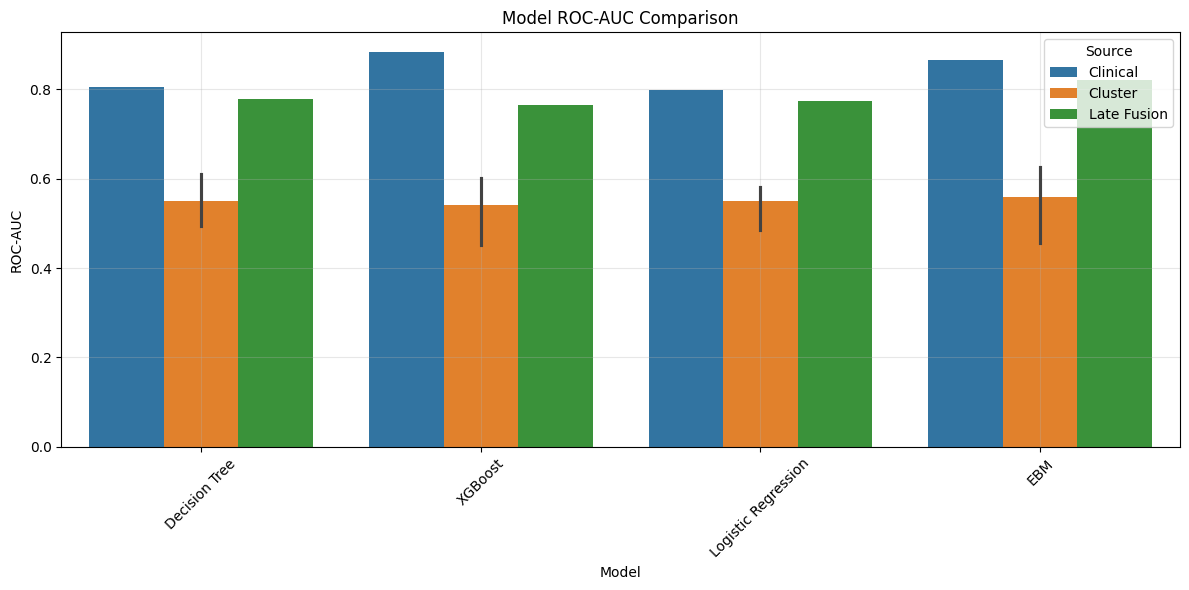

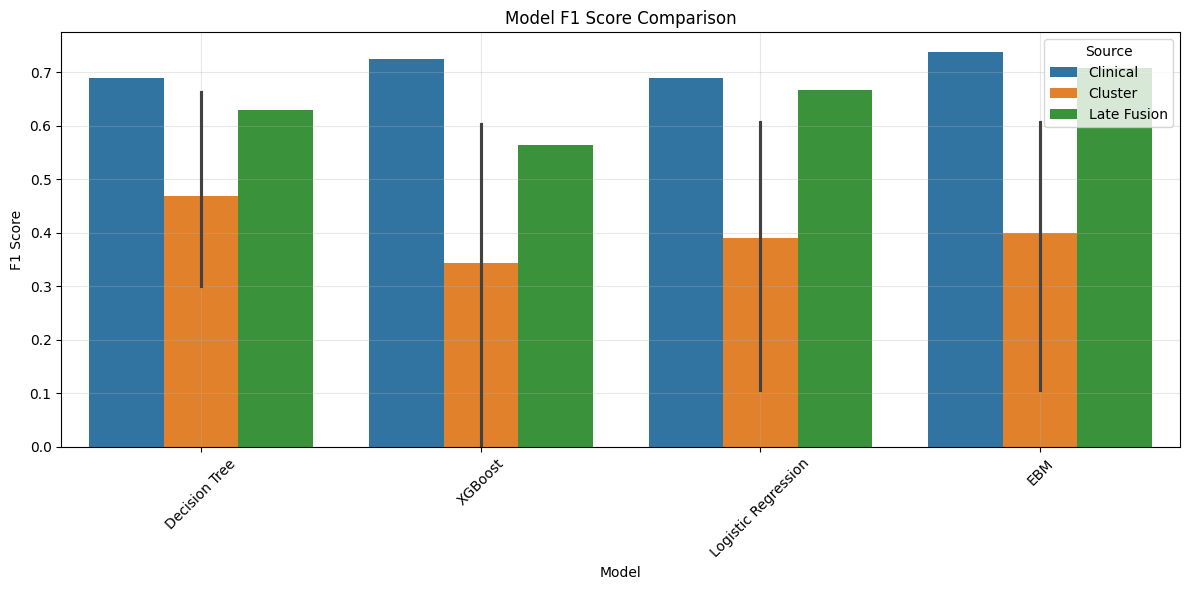

In [198]:
# ROC-AUC barplot
plt.figure(figsize=(12,6))
sns.barplot(data=all_results, x="Model", y="ROC-AUC", hue="Source")
plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# F1 score barplot
plt.figure(figsize=(12,6))
sns.barplot(data=all_results, x="Model", y="F1 Score", hue="Source")
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **XAI**

The methods of explainability were used for the selected best models in this section. This helped to determine what features or prediction sources were affecting the predictions of survival and to add transparency to the study which is really crucial for healthcare settings.

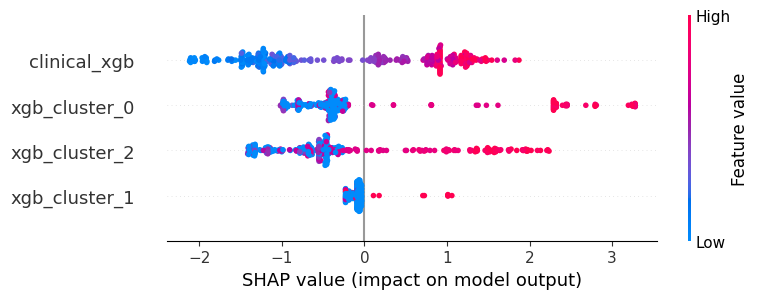

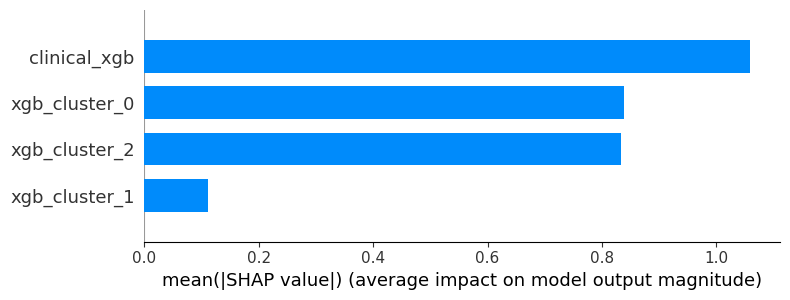

In [ ]:
#late fusion xgboost shap
xgb_explainer = shap.TreeExplainer(best_xgb_meta)
xgb_shap_values = xgb_explainer.shap_values(meta_X_test_xgb)
shap.summary_plot(xgb_shap_values, meta_X_test_xgb, max_display=10)
shap.summary_plot(xgb_shap_values, meta_X_test_xgb, plot_type="bar", max_display=10)

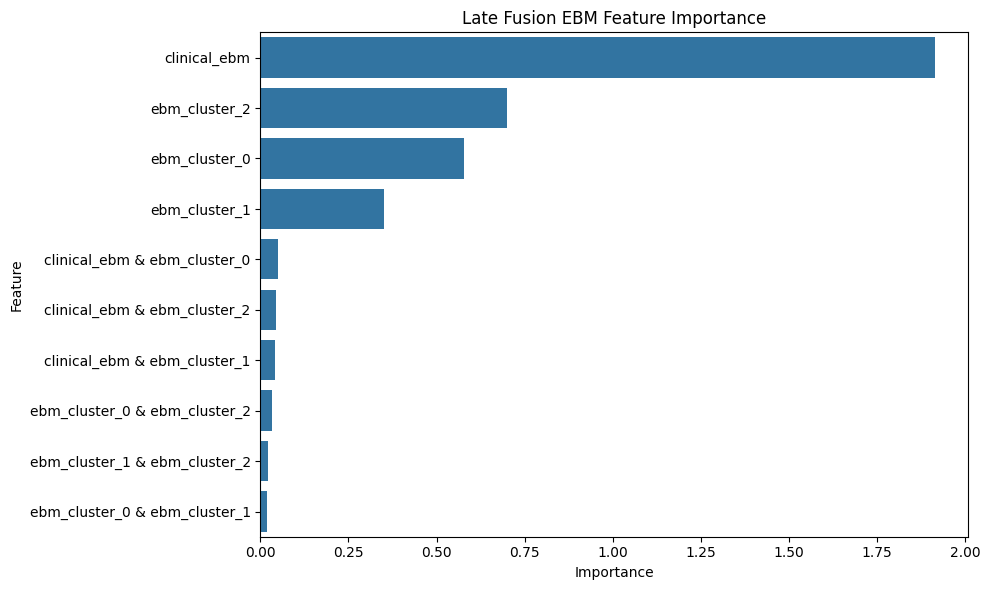

In [190]:
# late fusion ebm feature importance
ebm_global = best_ebm_meta.explain_global()
ebm_importance = pd.DataFrame({
    "Feature": ebm_global.data()["names"],
    "Importance": ebm_global.data()["scores"]
})

ebm_importance = ebm_importance.sort_values(by="Importance",ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=ebm_importance.head(10), x="Importance", y="Feature")
plt.title("Late Fusion EBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

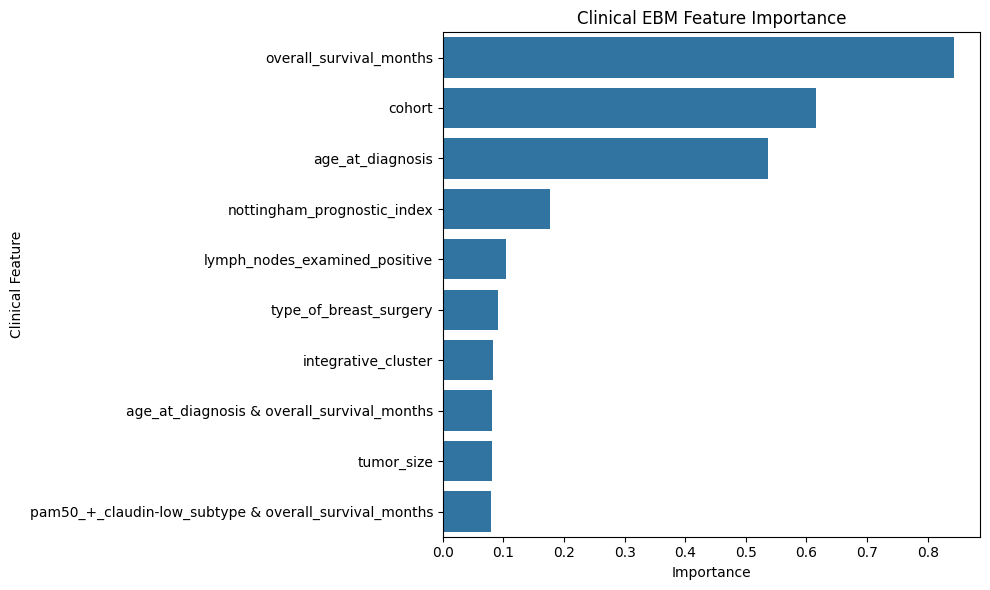

In [ ]:
# clinical ebm feature importance
clinical_ebm_global = best_ebm_clin.explain_global()
clinical_ebm_importance = pd.DataFrame({
    "Feature": clinical_ebm_global.data()["names"],
    "Importance": clinical_ebm_global.data()["scores"]
})
clinical_ebm_importance = clinical_ebm_importance.sort_values(by="Importance",ascending=False)

# get original columns names
clinical_feature_names = X.columns[:gene_start]

# replace generic ebm feature names with original column names
clinical_name_map = {
    f"feature_{i:04d}": col
    for i, col in enumerate(clinical_feature_names)
}

for old_name, real_name in clinical_name_map.items():
    clinical_ebm_importance["Feature"] = (
        clinical_ebm_importance["Feature"]
        .str.replace(old_name, real_name, regex=False)
    )


plt.figure(figsize=(10, 6))
sns.barplot(
    data=clinical_ebm_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Clinical EBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Clinical Feature")
plt.tight_layout()
plt.show()